## 6. Case-Level Throughput Prediction and Vendor Award Prediction

Invoice-to-Payment Process Optimization — Extension

*See the [README](#) for full project overview, business problem, and dataset details.*

Based on the feature engineering in Notebook 5, this notebook builds three
predictive models:

**Part 1 — Case-Level Throughput Prediction:** predicts `gr_to_clear_days`
(continuous) for individual cases, using case-level attributes and vendor
tier as features (`part1_features.parquet`). A strict "as-of-Goods-Receipt"
prediction point is enforced throughout, and results are cross-validated
against [Rząd et al. (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-2.pdf),
who performed similar predictive modeling on this dataset.

**Part 2 — Vendor Award Prediction:** predicts whether a vendor achieves an
award tier (No Award/Bronze/Silver+ — see Notebook 5 for the tier
construction methodology and citations), built as two variants:

* **Model A (existing vendors):** uses aggregated vendor-level features —
  category mix, order value, exception-activity rates, document
  type/spend classification mix — built from a vendor's own case history
  (`part2a_features.parquet`); Logistic Regression and Decision Tree are
  both tested
* **Model B (new vendors):** uses only order-level attributes knowable
  before any vendor-specific history exists, applied to vendors without
  enough history for Model A (`part2b_features.parquet`)

This notebook closes with an overall synthesis of findings across both
parts (6.5) and a transparent account of methodological limitations and
directions for further research (6.6).

## 6.1 Setup

- Load the three feature tables exported from Notebook 5
- Rebuild the raw event log (`event_log_p2p`), throughput deltas, and
  vendor tier ratings (`vendor_ratings_full`) — needed for the scoring-set
  steps in 6.3.7/6.4.1, since unfinished cases and vendor ratings were not
  carried over from the NB5 exports
- Imports: models, Optuna (search results are hardcoded from prior runs
  rather than re-executed — see 6.3.3/6.4.2), Weights & Biases tracking

In [ ]:
# Package installs
!pip install optuna --quiet
!pip install wandb --quiet
!pip install pm4py --quiet

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import optuna
import pm4py

from sklearn.model_selection import (
    GroupShuffleSplit, cross_val_score, cross_val_predict,
    StratifiedKFold, GridSearchCV, train_test_split
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

import joblib
from google.colab import userdata, drive

import wandb

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the three feature tables exported from Notebook 5
BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/"

part1_features = pd.read_parquet(BASE_PATH + "part1_features.parquet")
part2a_features = pd.read_parquet(BASE_PATH + "part2a_features.parquet")
part2b_features = pd.read_parquet(BASE_PATH + "part2b_features.parquet")

print(f"Part 1: {part1_features.shape}")
print(f"Part 2, Model A: {part2a_features.shape}")
print(f"Part 2, Model B: {part2b_features.shape}")

Part 1: (181552, 25)
Part 2, Model A: (445, 24)
Part 2, Model B: (221242, 10)


## 6.2 Feature Table Review

- Review the three loaded feature tables (`head()`, `.info()`, `.describe()`) before
  building any splits or models — confirm dtypes, check for unexpected
  nulls, sanity-check distributions against Notebook 5's validated figures

In [ ]:
# View head of feature table part 1

part1_features.head()

,item_category,spend_area,sub_spend_area,document_type,purchasing_document,item_type,purch_doc_category,spend_classification,source,gr_based_inv_verif,...,flag_change_currency,flag_change_price,flag_change_quantity,flag_change_storage_location,flag_change_payment_term,flag_delete_purchase_order_item,flag_update_order_confirmation,vendor,vendor_tier,target_gr_to_clear_days
case:concept:name,,,,,,,,,,,,,,,,,,,,,
4507000221_00010,"3-way match, invoice before GR",Packaging,Labels,Standard PO,4507000221,Standard,Purchase order,PR,sourceSystemID_0000,False,...,0,0,0,0,0,0,0,vendor_0103,No Award,110.859722
4507000222_00010,"3-way match, invoice before GR",Packaging,Labels,Standard PO,4507000222,Standard,Purchase order,PR,sourceSystemID_0000,False,...,0,0,0,0,0,0,0,vendor_0103,No Award,110.858333
4507000222_00020,"3-way match, invoice before GR",Packaging,Labels,Standard PO,4507000222,Standard,Purchase order,PR,sourceSystemID_0000,False,...,0,0,0,0,0,0,0,vendor_0103,No Award,110.858333
4507000223_00010,"3-way match, invoice before GR",Packaging,Plastic Containers & Lids < 30L,Standard PO,4507000223,Standard,Purchase order,PR,sourceSystemID_0000,False,...,0,0,0,0,0,0,0,vendor_0104,No Award,85.109028
4507000224_00010,"3-way match, invoice before GR",Packaging,Labels,Standard PO,4507000224,Standard,Purchase order,PR,sourceSystemID_0000,False,...,0,0,0,0,0,0,0,vendor_0105,No Award,49.109028


In [ ]:
part1_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 181552 entries, 4507000221_00010 to 4508075913_00040
Data columns (total 25 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   item_category                            181552 non-null  object 
 1   spend_area                               181552 non-null  object 
 2   sub_spend_area                           181552 non-null  object 
 3   document_type                            181552 non-null  object 
 4   purchasing_document                      181552 non-null  object 
 5   item_type                                181552 non-null  object 
 6   purch_doc_category                       181552 non-null  object 
 7   spend_classification                     181552 non-null  object 
 8   source                                   181552 non-null  object 
 9   gr_based_inv_verif                       181552 non-null  bool   
 10  item_line_po

In [ ]:
part1_features.describe(include='all')

,item_category,spend_area,sub_spend_area,document_type,purchasing_document,item_type,purch_doc_category,spend_classification,source,gr_based_inv_verif,...,flag_change_currency,flag_change_price,flag_change_quantity,flag_change_storage_location,flag_change_payment_term,flag_delete_purchase_order_item,flag_update_order_confirmation,vendor,vendor_tier,target_gr_to_clear_days
count,181552,181552,181552,181552,181552,181552,181552,181552,181552,181552,...,181552.000000,181552.000000,181552.000000,181552.000000,181552.000000,181552.000000,181552.000000,181552,181552,181552.000000
unique,2,19,116,2,52065,4,1,4,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1292,5,NaN
top,"3-way match, invoice before GR",Packaging,Products for Resale,Standard PO,4507016120,Standard,Purchase order,PR,sourceSystemID_0000,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,vendor_0135,No Award,NaN
freq,172326,76528,52231,181184,261,173106,181552,114922,181552,172326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10551,103372,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000143,0.033528,0.061762,0.001261,0.000022,0.001245,0.000969,NaN,NaN,65.933924
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.011966,0.180010,0.240723,0.035493,0.004694,0.035260,0.031120,NaN,NaN,30.452000
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.091667
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,44.857639
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,63.055556
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,85.910590


In [ ]:
# Check item_line_position

print(part1_features['item_line_position'].describe())
print(f"\nUnique values: {part1_features['item_line_position'].nunique()}")

count     181552
unique       311
top        00010
freq       46865
Name: item_line_position, dtype: object

Unique values: 311


In [ ]:
# View head of feature table part 2a

part2a_features.head()

,pct_2-way_match,pct_3-way_match_invoice_after_gr,pct_3-way_match_invoice_before_gr,median_order_value,n_cases,rate_block_purchase_order_item,rate_cancel_goods_receipt,rate_cancel_invoice_receipt,rate_change_approval_for_purchase_order,rate_change_currency,...,rate_delete_purchase_order_item,rate_record_subsequent_invoice,rate_update_order_confirmation,pct_doctype_framework_order,pct_doctype_standard_po,pct_spendclass_missing,pct_spendclass_npr,pct_spendclass_other,pct_spendclass_pr,target_award_tier
case:Name,,,,,,,,,,,,,,,,,,,,,
vendor_0032,0.0,0.000000,100.000000,1794.0,87,0.0,1.149425,2.298851,0.0,0.0,...,0.000000,0.0,0.0,0.0,100.0,0.000000,0.000000,0.0,100.000000,No Award
vendor_0036,0.0,22.142857,77.857143,3550.0,140,0.0,0.000000,2.857143,0.0,0.0,...,7.142857,0.0,0.0,0.0,100.0,0.000000,0.000000,0.0,100.000000,No Award
vendor_0042,0.0,2.105263,97.894737,2323.0,95,0.0,2.105263,1.052632,0.0,0.0,...,2.105263,0.0,0.0,0.0,100.0,2.105263,0.000000,0.0,97.894737,No Award
vendor_0056,0.0,0.000000,100.000000,4885.0,175,0.0,0.571429,1.142857,0.0,0.0,...,2.285714,0.0,0.0,0.0,100.0,0.000000,100.000000,0.0,0.000000,Bronze
vendor_0060,0.0,0.000000,100.000000,353.0,73,0.0,0.000000,1.369863,0.0,0.0,...,0.000000,0.0,0.0,0.0,100.0,0.000000,1.369863,0.0,98.630137,No Award


In [ ]:
part2a_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 445 entries, vendor_0032 to vendor_1614
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   pct_2-way_match                          445 non-null    float64
 1   pct_3-way_match_invoice_after_gr         445 non-null    float64
 2   pct_3-way_match_invoice_before_gr        445 non-null    float64
 3   median_order_value                       445 non-null    float64
 4   n_cases                                  445 non-null    int64  
 5   rate_block_purchase_order_item           445 non-null    float64
 6   rate_cancel_goods_receipt                445 non-null    float64
 7   rate_cancel_invoice_receipt              445 non-null    float64
 8   rate_change_approval_for_purchase_order  445 non-null    float64
 9   rate_change_currency                     445 non-null    float64
 10  rate_change_price                    

In [ ]:
part2a_features.describe(include='all')

,pct_2-way_match,pct_3-way_match_invoice_after_gr,pct_3-way_match_invoice_before_gr,median_order_value,n_cases,rate_block_purchase_order_item,rate_cancel_goods_receipt,rate_cancel_invoice_receipt,rate_change_approval_for_purchase_order,rate_change_currency,...,rate_delete_purchase_order_item,rate_record_subsequent_invoice,rate_update_order_confirmation,pct_doctype_framework_order,pct_doctype_standard_po,pct_spendclass_missing,pct_spendclass_npr,pct_spendclass_other,pct_spendclass_pr,target_award_tier
count,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,...,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445.000000,445
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No Award
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,233
mean,0.224719,7.583268,92.192013,5388.569663,497.173034,0.323096,1.252748,2.977430,0.725838,0.012002,...,2.902328,0.082435,0.143047,0.320348,99.679652,1.532990,39.429818,1.435350,57.601843,NaN
std,4.740455,21.405566,21.846150,12643.282969,1309.965021,2.411609,4.731598,4.625139,5.769449,0.146919,...,4.155197,0.329909,1.458680,4.757429,4.757429,5.841921,47.726587,9.364146,46.519635,NaN
min,0.000000,0.000000,0.000000,29.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.000000,0.000000,98.969072,499.000000,64.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,0.000000,0.000000,100.000000,1794.000000,122.000000,0.000000,0.000000,1.538462,0.000000,0.000000,...,1.639344,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,91.235955,NaN
75%,0.000000,0.899440,100.000000,4295.000000,365.000000,0.000000,1.232394,3.726708,0.000000,0.000000,...,3.846154,0.000000,0.000000,0.000000,100.000000,0.000000,100.000000,0.000000,99.920823,NaN


In [ ]:
# View head of feature table part 2b

part2b_features.head()

,item_category,spend_area,sub_spend_area,spend_classification,document_type,item_type,item_line_position,order_value,vendor,target_award_tier
case:concept:name,,,,,,,,,,
4507000221_00010,"3-way match, invoice before GR",Packaging,Labels,PR,Standard PO,Standard,00010,208.0,vendor_0103,No Award
4507000222_00010,"3-way match, invoice before GR",Packaging,Labels,PR,Standard PO,Standard,00010,42.0,vendor_0103,No Award
4507000222_00020,"3-way match, invoice before GR",Packaging,Labels,PR,Standard PO,Standard,00020,134.0,vendor_0103,No Award
4507000223_00010,"3-way match, invoice before GR",Packaging,Plastic Containers & Lids < 30L,PR,Standard PO,Standard,00010,867.0,vendor_0104,No Award
4507000224_00010,"3-way match, invoice before GR",Packaging,Labels,PR,Standard PO,Standard,00010,42.0,vendor_0105,No Award


In [ ]:
part2b_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221242 entries, 4507000221_00010 to 4508076331_00010
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   item_category         221242 non-null  object 
 1   spend_area            221242 non-null  object 
 2   sub_spend_area        221242 non-null  object 
 3   spend_classification  221242 non-null  object 
 4   document_type         221242 non-null  object 
 5   item_type             221242 non-null  object 
 6   item_line_position    221242 non-null  object 
 7   order_value           221242 non-null  float64
 8   vendor                221242 non-null  object 
 9   target_award_tier     221242 non-null  object 
dtypes: float64(1), object(9)
memory usage: 18.6+ MB


In [ ]:
part2b_features.describe(include='all')

,item_category,spend_area,sub_spend_area,spend_classification,document_type,item_type,item_line_position,order_value,vendor,target_award_tier
count,221242,221242,221242,221242,221242,221242,221242,2.212420e+05,221242,221242
unique,3,20,102,4,2,5,481,NaN,445,3
top,"3-way match, invoice before GR",Packaging,Products for Resale,PR,Standard PO,Standard,00010,NaN,vendor_0135,No Award
freq,210384,98863,59910,144266,221003,210277,52676,NaN,14471,139658
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.297650e+03,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.633031e+04,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.860000e+02,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.610000e+02,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.024000e+03,NaN,NaN


In [ ]:
print("Highest order values:")
print(part2b_features.nlargest(5, 'order_value')[['item_category', 'order_value', 'vendor']])

print(f"\nCases with order_value == 0: {(part2b_features['order_value'] == 0).sum()}")
print(f"\nLowest nonzero order values:")
print(part2b_features[part2b_features['order_value'] > 0].nsmallest(5, 'order_value')[['item_category', 'order_value', 'vendor']])

Highest order values:
                                    item_category  order_value       vendor
case:concept:name                                                          
4508056467_00020   3-way match, invoice before GR    4650187.0  vendor_0197
4508072057_00030   3-way match, invoice before GR    3772406.0  vendor_0158
4508050376_00020    3-way match, invoice after GR     959123.0  vendor_0119
4508055775_00010   3-way match, invoice before GR     547328.0  vendor_0332
4507011575_00020   3-way match, invoice before GR     408642.0  vendor_0154

Cases with order_value == 0: 1269

Lowest nonzero order values:
                                    item_category  order_value       vendor
case:concept:name                                                          
4507000252_00110   3-way match, invoice before GR          1.0  vendor_0122
4507000252_00130    3-way match, invoice after GR          1.0  vendor_0122
4507002931_00030   3-way match, invoice before GR          1.0  vendor_0169
4

In [ ]:
# Check whether zero-value cases cluster anywhere specific, or spread evenly

zero_value_cases = part2b_features[part2b_features['order_value'] == 0]
print(zero_value_cases['item_category'].value_counts())
print(f"\n{zero_value_cases['target_award_tier'].value_counts()}")

item_category
3-way match, invoice before GR    1264
3-way match, invoice after GR        5
Name: count, dtype: int64

target_award_tier
No Award    762
Bronze      396
Silver+     111
Name: count, dtype: int64


**Key insight — Feature table review:**

All three exported tables pass structural validation (zero unexpected
nulls, correct dtypes, summary statistics matching Notebook 5's validated
figures exactly).

Two right-skewed continuous features are flagged for log-transformation
ahead of Linear/Logistic Regression specifically (tree-based models handle
skew natively): Part 1's `target_gr_to_clear_days` and Part 2's
`order_value`/`median_order_value`. Model B's extreme order values
(€0 to €4.65M) were investigated and confirmed genuine — spread across
multiple vendors and categories with no unusual clustering by target tier,
consistent with a large industrial buyer's real order-size range rather
than a data artifact.

## 6.3 Part 1 — Case-Level Throughput Prediction

### 6.3.1 Train/Validation/Test Split

- Check whether cases should be grouped by `purchasing_document` before
  splitting — if many cases share the same PO, a random split could let
  closely related cases leak across train and test

In [ ]:
po_case_counts = part1_features['purchasing_document'].value_counts()

n_pos_total = len(po_case_counts)
n_pos_multi = (po_case_counts > 1).sum()
pct_pos_multi = n_pos_multi / n_pos_total * 100

n_cases_total = len(part1_features)
n_cases_multi = (part1_features['purchasing_document'].map(po_case_counts) > 1).sum()
pct_cases_multi = n_cases_multi / n_cases_total * 100

print(po_case_counts.describe())
print(f"\nPOs with more than one case: {n_pos_multi:,} of {n_pos_total:,} ({pct_pos_multi:.1f}%)")
print(f"Cases belonging to a multi-case PO: {n_cases_multi:,} of {n_cases_total:,} ({pct_cases_multi:.1f}%)")

count    52065.000000
mean         3.487026
std          6.768373
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        261.000000
Name: count, dtype: float64

POs with more than one case: 21,249 of 52,065 (40.8%)
Cases belonging to a multi-case PO: 150,736 of 181,552 (83.0%)


*Methodological note:* Given 83.0% of cases (150,736 of 181,552) share a
purchasing document with at least one other case, a grouped split is
required — cases from the same PO likely share order context and
correlated processing speed. Standard `train_test_split` risks leaking
closely related cases across train and test; `GroupShuffleSplit`, grouped
by `purchasing_document`, is used instead.

In [ ]:
# First split: 80% train, 20% temp (validation + test), grouped by purchasing_document
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss1.split(part1_features, groups=part1_features['purchasing_document']))

train_df = part1_features.iloc[train_idx]
temp_df = part1_features.iloc[temp_idx]

# Second split: divide temp into validation (10%) and test (10%), still grouped
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['purchasing_document']))

val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

print(f"Train: {len(train_df):,} ({len(train_df)/len(part1_features)*100:.1f}%)")
print(f"Validation: {len(val_df):,} ({len(val_df)/len(part1_features)*100:.1f}%)")
print(f"Test: {len(test_df):,} ({len(test_df)/len(part1_features)*100:.1f}%)")

train_pos = set(train_df['purchasing_document'])
val_pos = set(val_df['purchasing_document'])
test_pos = set(test_df['purchasing_document'])

print(f"\nPO overlap train/val: {len(train_pos & val_pos)}")
print(f"PO overlap train/test: {len(train_pos & test_pos)}")
print(f"PO overlap val/test: {len(val_pos & test_pos)}")

Train: 145,029 (79.9%)
Validation: 18,743 (10.3%)
Test: 17,780 (9.8%)

PO overlap train/val: 0
PO overlap train/test: 0
PO overlap val/test: 0


*Methodological note:* Different train/validate/test splits are widely used  (e.g. 60/20/20, 70/15/15, 80/10/10). Here 80/10/10 is used since it maximizes training data (which tends to help tree-based models and Optuna tuning in particular) without meaningfully weakening the reliability of validation/test given how large even 10% is in absolute terms.

### 6.3.2 Baseline Models

- Categorical features one-hot encoded; `item_line_position` converted to
  an ordinal numeric feature first (its genuine meaning), reducing the
  encoded feature count from 467 to 158 columns
- `purchasing_document` excluded from the model matrix (high-cardinality
  identifier, per 5.2.4's note) but retained as the grouping key for the
  split performed in 6.3.1
- Linear Regression fit on the log-transformed target (right-skew noted
  in 6.2's Feature Table Review); Decision Tree, Random Forest, and
  XGBoost fit on the raw target, since tree-based models handle skew
  natively

In [ ]:
# Columns to exclude from the model matrix: identifiers/traceability fields,
# not genuine predictors (per 5.2.4's note on purchasing_document)
exclude_from_model = ['purchasing_document', 'vendor', 'target_gr_to_clear_days']

feature_cols = [c for c in part1_features.columns if c not in exclude_from_model]
categorical_cols = [c for c in feature_cols if part1_features[c].dtype == 'object' or part1_features[c].dtype == 'bool']

print(f"Feature columns: {len(feature_cols)}")
print(f"Categorical columns to encode: {categorical_cols}")

# One-hot encode categoricals, fit on train only, apply consistently to val/test
X_train = pd.get_dummies(train_df[feature_cols], columns=categorical_cols, drop_first=True)
X_val = pd.get_dummies(val_df[feature_cols], columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(test_df[feature_cols], columns=categorical_cols, drop_first=True)

# Align val/test columns to match train exactly (handles any category present
# in one split but not another)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['target_gr_to_clear_days']
y_val = val_df['target_gr_to_clear_days']
y_test = test_df['target_gr_to_clear_days']

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

Feature columns: 22
Categorical columns to encode: ['item_category', 'spend_area', 'sub_spend_area', 'document_type', 'item_type', 'purch_doc_category', 'spend_classification', 'source', 'gr_based_inv_verif', 'item_line_position', 'vendor_tier']

X_train shape: (145029, 467)
X_val shape: (18743, 467)
X_test shape: (17780, 467)


In [ ]:
# item_line_position should be numeric (ordinal meaning: 1, 2, 3...), not
# one-hot encoded — recompute as integer position rather than string category
for df_name, df in [('part1_features', part1_features)]:
    df['item_line_position_numeric'] = df['item_line_position'].astype(int) // 10

# Rebuild the split dataframes with this new column, and exclude the old string version
train_df = part1_features.loc[train_df.index]
val_df = part1_features.loc[val_df.index]
test_df = part1_features.loc[test_df.index]

exclude_from_model = ['purchasing_document', 'vendor', 'target_gr_to_clear_days', 'item_line_position']

feature_cols = [c for c in part1_features.columns if c not in exclude_from_model]
categorical_cols = [c for c in feature_cols if part1_features[c].dtype == 'object' or part1_features[c].dtype == 'bool']

print(f"Feature columns: {len(feature_cols)}")
print(f"Categorical columns to encode: {categorical_cols}")

X_train = pd.get_dummies(train_df[feature_cols], columns=categorical_cols, drop_first=True)
X_val = pd.get_dummies(val_df[feature_cols], columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(test_df[feature_cols], columns=categorical_cols, drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df['target_gr_to_clear_days']
y_val = val_df['target_gr_to_clear_days']
y_test = test_df['target_gr_to_clear_days']

print(f"\nX_train shape: {X_train.shape}")

Feature columns: 22
Categorical columns to encode: ['item_category', 'spend_area', 'sub_spend_area', 'document_type', 'item_type', 'purch_doc_category', 'spend_classification', 'source', 'gr_based_inv_verif', 'vendor_tier']

X_train shape: (145029, 158)


In [ ]:
# Sanitize column names before fitting: XGBoost rejects [, ], < in feature
# names, which appear in some one-hot encoded categories (e.g. sub_spend_area
# values containing <)
import re

def sanitize_columns(df):
    df = df.copy()
    df.columns = [re.sub(r'[\[\]<]', '', str(col)) for col in df.columns]
    return df

X_train = sanitize_columns(X_train)
X_val = sanitize_columns(X_val)
X_test = sanitize_columns(X_test)

print(f"Duplicate column names after sanitizing: {X_train.columns.duplicated().sum()}")
print(f"X_train shape: {X_train.shape}")

Duplicate column names after sanitizing: 0
X_train shape: (145029, 158)


In [ ]:
# Fit Linear Regression (log-transformed target), Decision Tree, Random
# Forest, and XGBoost (raw target) on the training set
models = {}
val_predictions = {}

y_train_log = np.log1p(y_train)
lr = LinearRegression()
lr.fit(X_train, y_train_log)
models['Linear Regression'] = lr
val_predictions['Linear Regression'] = np.expm1(lr.predict(X_val))

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
models['Decision Tree'] = dt
val_predictions['Decision Tree'] = dt.predict(X_val)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
val_predictions['Random Forest'] = rf.predict(X_val)

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
models['XGBoost'] = xgb
val_predictions['XGBoost'] = xgb.predict(X_val)

print("All four models fitted successfully.")

All four models fitted successfully.


In [ ]:
# Evaluate all four models on the validation set (RMSE, MAE, R²)

results = []
for name, preds in val_predictions.items():
    mse = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2})

results_df = pd.DataFrame(results).set_index('Model')
results_df

,RMSE,MAE,R²
Model,,,
Linear Regression,21.703923,14.817078,0.487008
Decision Tree,25.428002,16.481675,0.295860
Random Forest,21.261455,13.969215,0.507711
XGBoost,20.060631,13.186067,0.561748


**Key insight — Baseline model comparison:**

All four models achieve meaningful predictive signal, with RMSE (20–25
days) well below the target's overall standard deviation (~30 days, per
4.2.3) — none are simply predicting the mean for every case.

* **XGBoost** is the clear leader across all three metrics simultaneously:
  lowest RMSE (20.06 days), lowest MAE (13.19 days), highest R² (0.562) —
  a clear victory, not a tradeoff between metrics
* **Random Forest** is a close second (RMSE 21.26, R² 0.508)
* **Linear Regression**, despite being the simplest model, performs
  competitively (RMSE 21.70, R² 0.487)
* **Decision Tree** is notably weaker than the other three (RMSE 25.43,
  R² 0.296), consistent with a single unconstrained tree tending to
  overfit relative to an ensemble or a regularized linear model

**Champion model:** XGBoost is selected as the champion model for Optuna
tuning (6.3.3).

*Methodological note:* **RMSE** (Root Mean Squared Error) shows the typical
prediction error in days, but penalizes large errors more heavily than
small ones. **MAE** (Mean Absolute Error) also shows the typical prediction
error in days, treating every error equally regardless of size. **R²**
(R-squared, or the coefficient of determination) shows what share of the
variation in throughput time the model explains, from 0 (no better than
guessing the average) to 1 (perfect prediction).

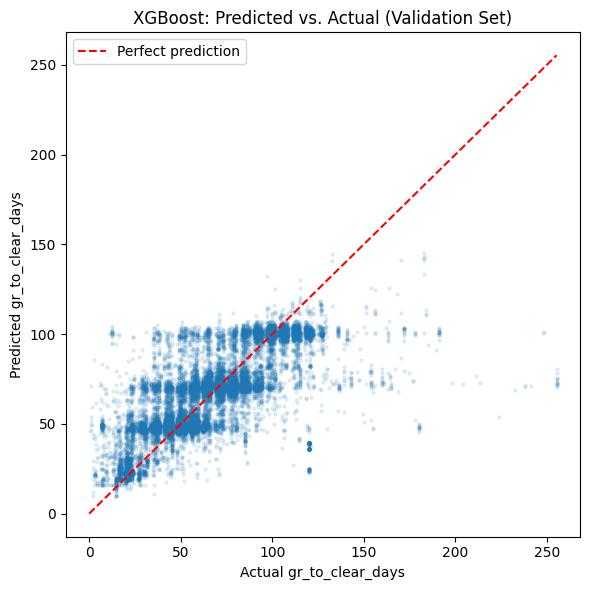

In [ ]:
# Predicted-vs-actual scatter plot for XGBoost

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, val_predictions['XGBoost'], alpha=0.1, s=5)
ax.plot([0, y_val.max()], [0, y_val.max()], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual gr_to_clear_days')
ax.set_ylabel('Predicted gr_to_clear_days')
ax.set_title('XGBoost: Predicted vs. Actual (Validation Set)')
ax.legend()
plt.tight_layout()
plt.show()

**Key insight — XGBoost predicted vs. actual (validation set):**

The Predicted-vs-actual scatter plot for XGBoost reveals the following:

- **Bulk of the distribution:** predictions track the diagonal closely for
  actual durations up to roughly 100 days, confirming genuine predictive
  signal across most of the data
- **Extreme cases underpredicted:** for actual durations above ~120–150
  days, predictions plateau around 70–100 days rather than continuing to
  track the diagonal — e.g. a case with an actual duration of 250 days is
  predicted at only ~70–100 days, a genuine underprediction of over 150
  days, rather than the model recognizing it as unusually extreme
- **Likely cause:** this is consistent with the right-skewed target
  distribution (4.2.4/6.2) — very long-duration cases are rare, giving the
  model comparatively little data to learn what drives the most extreme
  outcomes

**Overall business relevance:** this limitation matters most for Part 1's actual
  purpose — accurately flagging at-risk cases — since it is exactly the
  most severe delays where underprediction is weakest. Worth keeping in
  mind when interpreting predictions for genuinely extreme cases, and a
  candidate for further investigation (e.g. specialized handling of the
  long tail) beyond this notebook's current scope.

### 6.3.3 Hyperparameter Tuning (Optuna)

- Tune XGBoost, the champion model from 6.3.2, using Optuna to search for
  improved hyperparameters over the default settings
- Optimize directly on validation RMSE

In [ ]:
# # Tune XGBoost via Optuna, optimizing validation RMSE directly

# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 500),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'random_state': 42
#     }
#     model = XGBRegressor(**params)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_val)
#     rmse = np.sqrt(mean_squared_error(y_val, preds))
#     return rmse

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=30)

# print(f"Best RMSE: {study.best_value:.4f}")
# print(f"Best params: {study.best_params}")

**Key insight — Optuna tuning results:**

30 trials reduced validation RMSE from 20.06 days (default XGBoost) to
**19.80 days** — a modest but genuine improvement (~1.3%). Best
hyperparameters: `n_estimators=301`, `max_depth=9`, `learning_rate=0.113`,
`subsample=0.731`, `colsample_bytree=0.601`, `min_child_weight=4`. The
search converged gradually, with the best result found at trial 29 of 30,
suggesting further trials might yield small additional gains but with
diminishing returns.

*Methodological note:* In this run, the Optuna search was not re-executed
(the cell is commented out) — the hyperparameters above are already
verified and documented, so re-running the full 30-trial search would only
reproduce the same result at the cost of significant runtime. They are
applied directly for the XGBoost fit that follows.

In [ ]:
# # Refit champion model with tuned hyperparameters on the full training set,
# # evaluate on the held-out test set (unbiased, since test was never used
# # during hyperparameter selection)

# best_params = study.best_params
# best_params['random_state'] = 42

# xgb_final = XGBRegressor(**best_params)
# xgb_final.fit(X_train, y_train)

# test_preds = xgb_final.predict(X_test)

# test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
# test_mae = mean_absolute_error(y_test, test_preds)
# test_r2 = r2_score(y_test, test_preds)

# print(f"Test RMSE: {test_rmse:.2f} days")
# print(f"Test MAE: {test_mae:.2f} days")
# print(f"Test R²: {test_r2:.3f}")

In [ ]:
# Best hyperparameters from the Optuna search above, applied directly
best_params = {
    'n_estimators': 301,
    'max_depth': 9,
    'learning_rate': 0.11348107034418707,
    'subsample': 0.7311962064610965,
    'colsample_bytree': 0.6007668321007944,
    'min_child_weight': 4,
    'random_state': 42
}
xgb_final = XGBRegressor(**best_params)
xgb_final.fit(X_train, y_train)
test_preds = xgb_final.predict(X_test)
print("xgb_final fitted with known-verified hyperparameters (Optuna search skipped).")

xgb_final fitted with known-verified hyperparameters (Optuna search skipped).


In [ ]:
# Evaluate the champion model on the held-out test set
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

print(f"Test RMSE: {test_rmse:.2f} days")
print(f"Test MAE: {test_mae:.2f} days")
print(f"Test R²: {test_r2:.3f}")

Test RMSE: 20.05 days
Test MAE: 12.97 days
Test R²: 0.574


**Key insight — Final test-set performance:**

The tuned XGBoost model achieves **RMSE 20.05 days, MAE 12.97 days, R²
0.574** on the test set — never used during training or hyperparameter
selection, making this an unbiased estimate of real-world performance.
Results closely match validation-set figures (RMSE 19.80, MAE 13.19, R²
0.562), confirming the model generalizes well rather than overfitting to
validation-specific patterns.

**In practical terms:** on average, the model's throughput predictions are
off by about 13 days (MAE), explaining 57.4% of the variance in
`gr_to_clear_days` — a meaningful improvement over simply predicting the
average duration for every case.

### 6.3.4 Segmented Performance

- Check whether the champion model performs consistently across
  `item_category` and `vendor_tier` segments, or whether errors
  concentrate in specific groups

In [ ]:
# Segmented test-set performance by item_category
test_results_df = test_df.copy()
test_results_df['predicted'] = test_preds
test_results_df['abs_error'] = np.abs(test_results_df['predicted'] - test_results_df['target_gr_to_clear_days'])

segment_by_category = test_results_df.groupby('item_category').apply(
    lambda g: pd.Series({
        'n': len(g),
        'RMSE': np.sqrt(mean_squared_error(g['target_gr_to_clear_days'], g['predicted'])),
        'MAE': mean_absolute_error(g['target_gr_to_clear_days'], g['predicted']),
        'R2': r2_score(g['target_gr_to_clear_days'], g['predicted'])
    })
)
segment_by_category

/tmp/ipykernel_809/1030610064.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  segment_by_category = test_results_df.groupby('item_category').apply(


,n,RMSE,MAE,R2
item_category,,,,
"3-way match, invoice after GR",942.0,19.414399,14.190002,0.540611
"3-way match, invoice before GR",16838.0,20.080035,12.906718,0.575414


In [ ]:
segment_by_tier = test_results_df.groupby('vendor_tier').apply(
    lambda g: pd.Series({
        'n': len(g),
        'RMSE': np.sqrt(mean_squared_error(g['target_gr_to_clear_days'], g['predicted'])),
        'MAE': mean_absolute_error(g['target_gr_to_clear_days'], g['predicted']),
        'R2': r2_score(g['target_gr_to_clear_days'], g['predicted'])
    })
)
segment_by_tier

/tmp/ipykernel_809/193281658.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  segment_by_tier = test_results_df.groupby('vendor_tier').apply(


,n,RMSE,MAE,R2
vendor_tier,,,,
Bronze,5372.0,19.446395,11.527042,0.191577
Gold,990.0,10.766559,6.604655,0.219843
Insufficient Data,692.0,25.019473,18.693312,0.266170
No Award,10277.0,20.177385,13.781549,0.353580
Silver,449.0,29.122515,17.059408,0.444642


**Key insight — Segmented performance:**

- **By `item_category`:** performance is consistent with the overall model
  (RMSE 19.4–20.1 days across both categories, adequate sample sizes)
- **By `vendor_tier`:** R² drops sharply within every segment (0.19–0.44, vs.
  0.574 overall) — expected, not a flaw: R² reflects explained variance,
  and variance itself shrinks once conditioning on a variable already
  correlated with the outcome; RMSE/MAE are more informative here:
  **Gold vendors show the most accurate predictions** (RMSE 10.77, MAE
  6.60 days — roughly half the overall error), while **Silver** (RMSE
  29.12, n=449) and **Insufficient Data** (RMSE 25.02, n=692) show the
  weakest — plausibly reflecting higher unpredictability for
  less-established or lower-volume vendor relationships, especially given
  Silver's small sample size limits how generalizable that figure is

### 6.3.5 External Validation: Rząd et al. (2019) Cross-Validation

- Compare this model's exception-activity feature importance against  [Rząd et al. (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-2.pdf)'s reported "Undesired Activities" findings (Linear Regression and Random Forest, per cluster)
- Note upfront: Rząd et al.'s features were computed over each case's **full** history; this project's `flag_*` features are restricted to **pre-Goods-Receipt** occurrences only (6.3.2), so this is a qualitative comparison of which activities matter, not a like-for-like reproduction

In [ ]:
# Extract XGBoost feature importance, restricted to the exception-activity
# flags (our version of Rząd et al.'s "Undesired Activities")

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)

flag_importance = importance_df[importance_df['feature'].str.startswith('flag_')]
flag_importance = flag_importance.reset_index(drop=True)
flag_importance.index = flag_importance.index + 1

flag_importance

,feature,importance
1,flag_block_purchase_order_item,0.007900
2,flag_change_approval_for_purchase_order,0.004801
3,flag_cancel_invoice_receipt,0.002448
4,flag_change_price,0.002047
5,flag_change_storage_location,0.001408
6,flag_change_quantity,0.001327
7,flag_update_order_confirmation,0.000930
8,flag_delete_purchase_order_item,0.000882
9,flag_change_currency,0.000498
10,flag_change_payment_term,0.000173


**Key insight — Cross-validation against Rząd et al. (2019):**

Comparing exception-activity feature importance against
[Rząd et al. (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-2.pdf)'s
top "Undesired Activities" reveals a substantive methodological
divergence, not just a ranking difference:

- **Two of their three strongest predictors are absent here entirely** —
  "Record Subsequent Invoice" and "Cancel Goods Receipt" were both
  eliminated by the strict pre-Goods-Receipt filter (6.3.2), since neither
  legitimately occurs before GR (0 pre-GR occurrences for the former; the
  latter's 59 occurrences were all same-timestamp batch artifacts) —
  suggesting some of their predictive power relied on information not
  actually knowable at a genuine forecasting point
- **Where the studies agree, it's meaningful**: "Block Purchase Order
  Item" (rank 1) and "Change Approval for Purchase Order" (rank 2) — both
  plausible early-case activities — also ranked among Rząd et al.'s top
  predictors
- **Overall, exception-activity flags carry modest importance** (max
  0.0090), playing a minor role relative to static/categorical features

This shows how a prior study's most-cited findings can be excluded purely
by differences in scoping — the prediction point chosen, not the data
itself.

### 6.3.6 Overall Feature Importance

- Report XGBoost's top drivers across all features, not just the
  exception-activity flags examined in 6.3.5 — a broader view of what the
  champion model actually relies on

In [ ]:
top_features = importance_df.head(20).reset_index(drop=True)
top_features.index = top_features.index + 1
top_features

,feature,importance
1,sub_spend_area_Labels,0.153705
2,vendor_tier_No Award,0.097622
3,vendor_tier_Gold,0.089651
4,spend_classification_NPR,0.055552
5,spend_area_Packaging,0.040695
6,sub_spend_area_Plastic Containers & Lids 30L,0.033025
7,sub_spend_area_Color Collateral,0.031798
8,sub_spend_area_Trading products (old structure),0.021990
9,spend_classification_PR,0.021518
10,vendor_tier_Silver,0.016474


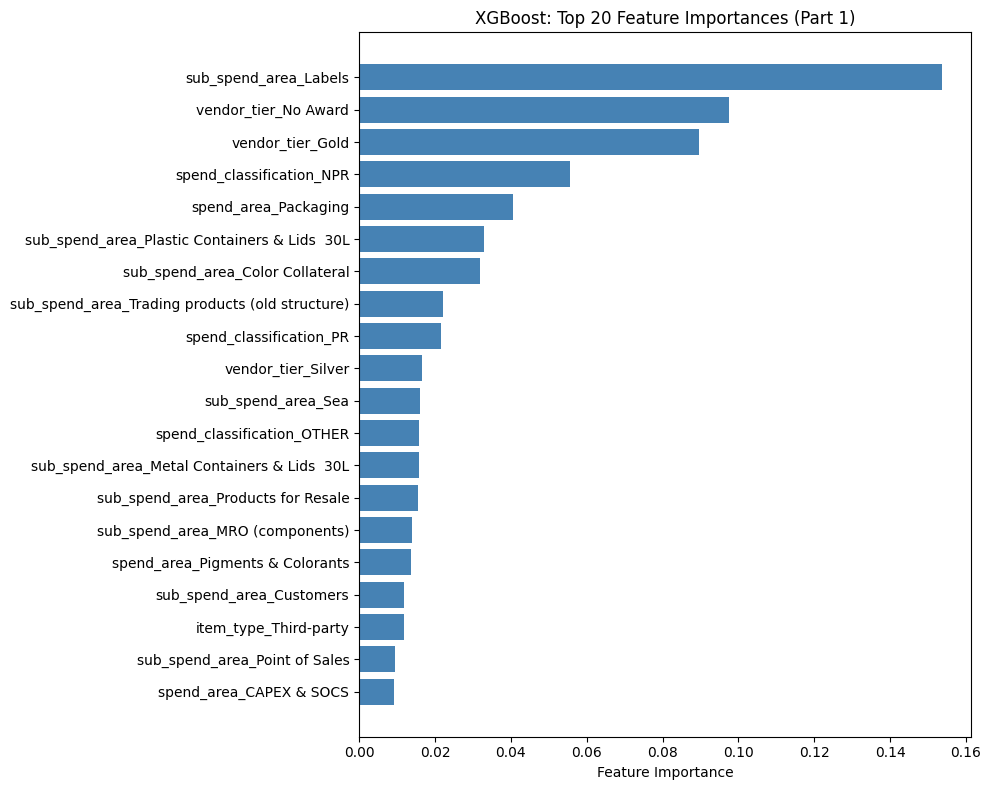

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_data = top_features.iloc[::-1]  # reverse so rank 1 appears at top

ax.barh(plot_data['feature'], plot_data['importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost: Top 20 Feature Importances (Part 1)')
plt.tight_layout()
plt.show()

In [ ]:
labels_cases = X_train[X_train['sub_spend_area_Labels'] == 1]
print(f"'Labels' cases in training set: {len(labels_cases):,} ({len(labels_cases)/len(X_train)*100:.1f}%)")
print(f"\nTarget stats for 'Labels' cases:")
print(y_train[X_train['sub_spend_area_Labels'] == 1].describe())
print(f"\nTarget stats for all other cases:")
print(y_train[X_train['sub_spend_area_Labels'] == 0].describe())

'Labels' cases in training set: 32,645 (22.5%)

Target stats for 'Labels' cases:
count    32645.000000
mean        91.788037
std         27.868957
min          1.585417
25%         72.752083
50%         99.123611
75%        111.661806
max        342.231944
Name: target_gr_to_clear_days, dtype: float64

Target stats for all other cases:
count    112384.000000
mean         58.332768
std          26.798514
min           0.091667
25%          41.705556
50%          57.107986
75%          73.259201
max         331.743750
Name: target_gr_to_clear_days, dtype: float64


**Key insight — Overall feature importance:**

The top-20 features are dominated by two categories, both consistent with
findings already established elsewhere in this project:

* **`sub_spend_area_Labels`** is the single strongest predictor (importance
  0.154) — confirmed as a genuine, robust pattern, not a small-sample
  artifact: 32,645 cases (22.5% of training data) belong to this
  sub-category, with a mean throughput of 91.79 days versus 58.33 days for
  all other cases
* **`vendor_tier`** dummy columns rank 2nd, 3rd, and 10th (No Award, Gold,
  Silver combined ≈ 0.204 importance) — expected and legitimate, given
  `vendor_tier` is deliberately built from a vendor's *other* completed
  cases (5.1), not the case being predicted; this is the model correctly
  leveraging a vendor's track record, not data leakage
* Exception-activity flags (examined separately in 6.3.5) are notably
  minor contributors by comparison — none appear within this run's top 20
  features at all

*Note:* some category labels containing "<" (e.g. "Plastic Containers &
Lids < 30L") display without the symbol — this is a side effect of the
column-sanitization fix applied in 6.3.2 for XGBoost compatibility, not a
data issue.

### 6.3.7 Apply champion model and score predictions

- Apply the tuned XGBoost model to the 38,047 scorable unfinished cases
  (already past Goods Receipt), generating live throughput estimates with
  no ground truth to validate against

In [ ]:
# Raw event log rebuild

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/BPI_2019_cleaned.parquet"
event_log = pd.read_parquet(DATA_PATH)

event_month_backup = event_log['event_month'].copy()
event_log_formatted = pm4py.format_dataframe(
    event_log, case_id='case:concept:name', activity_key='concept:name', timestamp_key='time:timestamp'
)
event_log_formatted['event_month'] = event_month_backup

srm_cases = event_log_formatted.loc[
    event_log_formatted['concept:name'].str.startswith('SRM:'), 'case:concept:name'
].unique()
event_log_p2p = event_log_formatted.drop(
    index=event_log_formatted[event_log_formatted['case:concept:name'].isin(srm_cases)].index
)

milestones = ['Record Goods Receipt', 'Record Invoice Receipt', 'Clear Invoice']
milestone_events = event_log_p2p[event_log_p2p['concept:name'].isin(milestones)]
first_occurrence = (
    milestone_events.sort_values(['case:concept:name', 'time:timestamp'])
    .groupby(['case:concept:name', 'concept:name'])['time:timestamp'].first().unstack('concept:name')
)
all_cases = event_log_p2p['case:concept:name'].unique()
first_occurrence_full = first_occurrence.reindex(all_cases)
finished_cases = set(event_log_p2p.loc[event_log_p2p['concept:name'] == 'Clear Invoice', 'case:concept:name'])

case_company_category = event_log_p2p.groupby('case:concept:name')[['case:Company', 'case:Item Category']].first()
three_way_categories = ['3-way match, invoice before GR', '3-way match, invoice after GR']
sample1_mask = (
    (case_company_category['case:Company'] == 'companyID_0000') &
    (case_company_category['case:Item Category'].isin(three_way_categories))
)
sample1_all = set(case_company_category[sample1_mask].index)
sample1_finished = sample1_all & finished_cases

print(f"Sample 1 total: {len(sample1_all):,}, finished: {len(sample1_finished):,}")

Sample 1 total: 234,748, finished: 182,206


In [ ]:
# Identify the scoring set: cases in Part 1's scope that have reached GR
# but not yet Clear Invoice (consistent with the "as of GR" prediction point)

scoring_candidates = sample1_all - sample1_finished

scoring_cases = [
    c for c in scoring_candidates
    if c in first_occurrence_full.index and pd.notna(first_occurrence_full.loc[c, 'Record Goods Receipt'])
]

print(f"Unfinished cases in Part 1's scope: {len(scoring_candidates):,}")
print(f"Of those, already past GR (scorable): {len(scoring_cases):,}")
print(f"Not yet at GR (outside this model's scope): {len(scoring_candidates) - len(scoring_cases):,}")

Unfinished cases in Part 1's scope: 52,542
Of those, already past GR (scorable): 38,047
Not yet at GR (outside this model's scope): 14,495


In [ ]:
# Build the feature table for the scoring set, using the same construction
# logic as Part 1's training features (5.2.2), but for unfinished cases

scoring_events = event_log_p2p[event_log_p2p['case:concept:name'].isin(scoring_cases)]

static_fields = [
    'case:Item Category', 'case:Spend area text', 'case:Sub spend area text',
    'case:Document Type', 'case:Purchasing Document', 'case:Item Type',
    'case:Purch. Doc. Category name', 'case:Spend classification text',
    'case:Source', 'case:GR-Based Inv. Verif.', 'case:Item',
    'Cumulative net worth (EUR)'
]

scoring_features = scoring_events.groupby('case:concept:name').first()[static_fields]
scoring_features = scoring_features.rename(columns={
    'case:Item Category': 'item_category', 'case:Spend area text': 'spend_area',
    'case:Sub spend area text': 'sub_spend_area', 'case:Document Type': 'document_type',
    'case:Purchasing Document': 'purchasing_document', 'case:Item Type': 'item_type',
    'case:Purch. Doc. Category name': 'purch_doc_category',
    'case:Spend classification text': 'spend_classification', 'case:Source': 'source',
    'case:GR-Based Inv. Verif.': 'gr_based_inv_verif', 'case:Item': 'item_line_position',
    'Cumulative net worth (EUR)': 'order_value'
})

print(f"Scoring feature table shape: {scoring_features.shape}")
# Expect: (38047, 12)

Scoring feature table shape: (38047, 12)


*Note on structure:* This scoring-set feature table is built here rather than in Notebook 5, since the trained model that will consume it did not exist before. In a future revision, this could be moved to Notebook 5 in section 5.2.2, since it uses identical logic.

In [ ]:
# Step 1 — Build static features for the scoring set
scoring_features = scoring_events.groupby('case:concept:name').first()[[
    'case:Item Category', 'case:Spend area text', 'case:Sub spend area text',
    'case:Document Type', 'case:Purchasing Document', 'case:Item Type',
    'case:Purch. Doc. Category name', 'case:Spend classification text',
    'case:Source', 'case:GR-Based Inv. Verif.', 'case:Item',
    'Cumulative net worth (EUR)'
]]
scoring_features = scoring_features.rename(columns={
    'case:Item Category': 'item_category', 'case:Spend area text': 'spend_area',
    'case:Sub spend area text': 'sub_spend_area', 'case:Document Type': 'document_type',
    'case:Purchasing Document': 'purchasing_document', 'case:Item Type': 'item_type',
    'case:Purch. Doc. Category name': 'purch_doc_category',
    'case:Spend classification text': 'spend_classification', 'case:Source': 'source',
    'case:GR-Based Inv. Verif.': 'gr_based_inv_verif', 'case:Item': 'item_line_position',
    'Cumulative net worth (EUR)': 'order_value'
})
print(f"Step 1 shape: {scoring_features.shape}")

Step 1 shape: (38047, 12)


In [ ]:
# Step 2 — Add exception-activity flags, filtered strictly before each
# case's own Goods Receipt timestamp (prevents hindsight leakage, see
# 6.3.2). Any flag column not present in training (e.g.
# flag_cancel_goods_receipt, eliminated as an artifact in 6.3.2) is
# dropped, since the model cannot use a feature it was never trained with.

case_gr_time_scoring = scoring_events[scoring_events['concept:name'] == 'Record Goods Receipt'] \
    .groupby('case:concept:name')['time:timestamp'].first()

undesired_activities = [
    'Block Purchase Order Item', 'Cancel Goods Receipt', 'Cancel Invoice Receipt',
    'Change Approval for Purchase Order', 'Change Currency', 'Change payment term',
    'Change Price', 'Change Quantity', 'Change Storage Location',
    'Delete Purchase Order Item', 'Record Subsequent Invoice', 'Update Order Confirmation'
]
undesired_events_scoring = scoring_events[scoring_events['concept:name'].isin(undesired_activities)].copy()
undesired_events_scoring['case_gr_time'] = undesired_events_scoring['case:concept:name'].map(case_gr_time_scoring)
undesired_events_scoring_pre_gr = undesired_events_scoring[
    undesired_events_scoring['time:timestamp'] < undesired_events_scoring['case_gr_time']
]

scoring_exception_flags = (
    undesired_events_scoring_pre_gr.groupby(['case:concept:name', 'concept:name'])
    .size().unstack(fill_value=0).clip(upper=1)
)
scoring_exception_flags = scoring_exception_flags.reindex(scoring_cases, fill_value=0)
scoring_exception_flags.columns = [f'flag_{c.lower().replace(" ", "_")}' for c in scoring_exception_flags.columns]

train_flag_cols = X_train.columns[X_train.columns.str.startswith('flag_')]
for col in train_flag_cols:
    if col not in scoring_exception_flags.columns:
        scoring_exception_flags[col] = 0
extra_flag_cols = [c for c in scoring_exception_flags.columns if c not in train_flag_cols]
scoring_exception_flags = scoring_exception_flags.drop(columns=extra_flag_cols, errors='ignore')

scoring_features = scoring_features.join(scoring_exception_flags)
print(f"Step 2 shape: {scoring_features.shape}")
print(f"Flag columns: {[c for c in scoring_features.columns if c.startswith('flag_')]}")

Step 2 shape: (38047, 22)
Flag columns: ['flag_block_purchase_order_item', 'flag_cancel_invoice_receipt', 'flag_change_approval_for_purchase_order', 'flag_change_currency', 'flag_change_price', 'flag_change_quantity', 'flag_change_storage_location', 'flag_change_payment_term', 'flag_delete_purchase_order_item', 'flag_update_order_confirmation']


In [ ]:
# Rebuild throughput deltas and vendor tier ratings (vendor_ratings_full) —
# needed for the scoring-set vendor-tier join below

MIN_CASES_FOR_RATING = 30

case_vendor = event_log_p2p.groupby('case:concept:name')['case:Name'].first()

milestones = ['Record Goods Receipt', 'Record Invoice Receipt', 'Clear Invoice']
milestone_events = event_log_p2p[event_log_p2p['concept:name'].isin(milestones)]
first_occurrence = (
    milestone_events.sort_values(['case:concept:name', 'time:timestamp'])
    .groupby(['case:concept:name', 'concept:name'])['time:timestamp'].first().unstack('concept:name')
)
all_cases = event_log_p2p['case:concept:name'].unique()
first_occurrence_full = first_occurrence.reindex(all_cases)

throughput = pd.DataFrame(index=first_occurrence_full.index)
throughput['gr_to_ir_days'] = (first_occurrence_full['Record Invoice Receipt'] - first_occurrence_full['Record Goods Receipt']).dt.total_seconds() / 86400
throughput['ir_to_clear_days'] = (first_occurrence_full['Clear Invoice'] - first_occurrence_full['Record Invoice Receipt']).dt.total_seconds() / 86400
throughput['gr_to_clear_days'] = (first_occurrence_full['Clear Invoice'] - first_occurrence_full['Record Goods Receipt']).dt.total_seconds() / 86400

throughput_by_vendor = throughput.join(case_vendor)

finished_only = throughput_by_vendor[
    throughput_by_vendor.index.isin(finished_cases) & throughput_by_vendor['ir_to_clear_days'].notna()
]

vendor_ratings = finished_only.groupby('case:Name').agg(
    n_cases=('ir_to_clear_days', 'count'),
    pct_within_30=('ir_to_clear_days', lambda x: (x <= 30).mean() * 100),
    pct_within_60=('ir_to_clear_days', lambda x: (x <= 60).mean() * 100),
)

def assign_tier(row):
    if row['n_cases'] < MIN_CASES_FOR_RATING: return 'Insufficient Data'
    elif row['pct_within_30'] >= 95: return 'Gold'
    elif row['pct_within_60'] >= 95 and row['pct_within_30'] >= 90: return 'Silver'
    elif row['pct_within_60'] >= 95: return 'Bronze'
    else: return 'No Award'
vendor_ratings['tier'] = vendor_ratings.apply(assign_tier, axis=1)

all_vendors = set(event_log_p2p['case:Name'].unique())
missing_vendors = all_vendors - set(vendor_ratings.index)
case_vendor_category = event_log_p2p.groupby('case:concept:name')[['case:Name', 'case:Item Category']].first()
missing_vc = case_vendor_category[case_vendor_category['case:Name'].isin(missing_vendors)].groupby('case:Name')['case:Item Category'].apply(lambda x: set(x.unique()))
applicable_cats = {'3-way match, invoice before GR', '3-way match, invoice after GR', '2-way match'}
consignment_only = missing_vc.apply(lambda cats: cats.isdisjoint(applicable_cats))
missing_vendor_tier = pd.DataFrame({'tier': consignment_only.map({True: 'Not Applicable', False: 'Insufficient Data'})})
missing_vendor_tier.index.name = 'case:Name'

vendor_ratings_full = pd.concat([vendor_ratings[['tier']], missing_vendor_tier])

print(f"Total vendors: {len(vendor_ratings_full):,}")
print(vendor_ratings_full['tier'].value_counts())

Total vendors: 1,674
tier
Insufficient Data    1222
No Award              233
Bronze                160
Gold                   39
Silver                 13
Not Applicable          7
Name: count, dtype: int64


In [ ]:
# Step 3 — Join vendor identity and vendor tier
case_vendor_map = event_log_p2p.groupby('case:concept:name')['case:Name'].first()
scoring_features['vendor'] = case_vendor_map.reindex(scoring_features.index)
scoring_features = scoring_features.join(
    vendor_ratings_full[['tier']].rename(columns={'tier': 'vendor_tier'}), on='vendor'
)

print(f"Step 3 shape: {scoring_features.shape}")
print(f"Missing values: {scoring_features.isna().sum().sum()}")

Step 3 shape: (38047, 24)
Missing values: 0


In [ ]:
# Step 4 — Encode, align to training columns, and apply the champion model
exclude_from_model = ['purchasing_document', 'vendor']
scoring_feature_cols = [c for c in scoring_features.columns if c not in exclude_from_model]
scoring_categorical_cols = [c for c in scoring_feature_cols if scoring_features[c].dtype == 'object' or scoring_features[c].dtype == 'bool']

X_scoring = pd.get_dummies(scoring_features[scoring_feature_cols], columns=scoring_categorical_cols, drop_first=True)
X_scoring = sanitize_columns(X_scoring)
X_scoring = X_scoring.reindex(columns=X_train.columns, fill_value=0)

scoring_predictions = xgb_final.predict(X_scoring)

scoring_results = scoring_features[['vendor', 'vendor_tier', 'order_value']].copy()
scoring_results['predicted_gr_to_clear_days'] = scoring_predictions

print(f"X_scoring shape: {X_scoring.shape}")
print(f"Scoring results shape: {scoring_results.shape}")
scoring_results.head()

X_scoring shape: (38047, 158)
Scoring results shape: (38047, 4)


,vendor,vendor_tier,order_value,predicted_gr_to_clear_days
case:concept:name,,,,
4507000252_00110,vendor_0122,Bronze,1.0,50.871895
4507000252_00120,vendor_0122,Bronze,0.0,50.871895
4507000252_00130,vendor_0122,Bronze,1.0,55.562328
4507000254_00060,vendor_0122,Bronze,0.0,50.871895
4507000472_00001,vendor_0228,Bronze,536.0,81.848862


In [ ]:
# Compare scoring-set predictions against the training set's actual outcomes,
# to see if the higher mean reflects genuine selection bias

print("Training set actual gr_to_clear_days:")
print(y_train.describe())

print("\nScoring set predicted gr_to_clear_days:")
print(scoring_results['predicted_gr_to_clear_days'].describe())

Training set actual gr_to_clear_days:
count    145029.000000
mean         65.863312
std          30.439379
min           0.091667
25%          44.823611
50%          62.995833
75%          85.877083
max         342.231944
Name: target_gr_to_clear_days, dtype: float64

Scoring set predicted gr_to_clear_days:
count    38047.000000
mean        83.198265
std         23.198254
min         10.303577
25%         69.383499
50%         79.541763
75%        103.844200
max        206.119751
Name: predicted_gr_to_clear_days, dtype: float64


In [ ]:
# Vendor tier results

scoring_results.groupby('vendor_tier')['predicted_gr_to_clear_days'].describe()

,count,mean,std,min,25%,50%,75%,max
vendor_tier,,,,,,,,
Bronze,6077.0,53.407253,13.865227,12.749092,47.880249,50.871895,53.647602,193.233292
Gold,421.0,31.549345,12.974878,10.303577,21.913780,26.249357,46.389591,67.677017
Insufficient Data,5507.0,105.514267,21.810736,36.051449,96.862274,105.309692,116.890526,206.119751
No Award,25693.0,86.804062,15.877924,20.152294,73.356209,82.947563,103.716652,156.484802
Silver,349.0,46.654701,15.222953,14.970077,35.954502,41.820015,57.827667,107.464211


**Key insight — Scoring set predictions:**

Applying the **champion model** to the 38,047 scorable unfinished cases
(already past Goods Receipt) yields predicted clearing times that vary
substantially by vendor tier — reflecting the same predicted-throughput
pattern established for the training set, applied here to open cases.

Segmenting by `vendor_tier`:

- **Gold:** 31.55 days on average (median 26.25) — clearly the **fastest**
  of all tiers
- **Silver:** 46.65 days
- **Bronze:** 53.41 days
- **No Award:** 86.80 days (median 82.95) — these vendors sit mostly well
  above the 60-day payment line, consistent with not qualifying for even
  Bronze status
- **Insufficient Data:** 105.51 days (median 105.31) — the **slowest** of
  any tier

According to these findings, three types deserve detailed explanation due
to their business implications:

* **Gold vendors:** their invoicing process is fast and requires little
  resource-intensive rework, letting most invoices be paid within 30 days;
  fast enough that, in principle, this could support early-payment
  discount terms if such arrangements exist with these vendors — a clearly
  favorable vendor type, however, at 421 cases, this is the second-smallest
  group in the scoring set after Silver (349)
* **"Insufficient Data" vendors:** this finding is particularly actionable;
  vendors without enough history for a formal rating are predicted to have
  the slowest open cases, suggesting their low transaction volume and their
  comparatively poor invoicing processing speed may share a common
  underlying cause (e.g. a less established vendor relationship, or weaker
  internal invoicing standards on their side) — this makes "Insufficient
  Data" vendors a meaningful candidate group for closer monitoring
* **"No Award" vendors:** a similar underlying-cause explanation likely
  applies here too, though the predicted delay is somewhat less severe
  (mean 86.80 days, median 82.95, vs. 105.51/105.31 for "Insufficient
  Data") — however, its sheer size at 25,693 cases (68% of the scoring
  set, the largest segment) means even a moderate per-case delay
  translates into substantial aggregate business impact, warranting
  equally close monitoring

### 6.3.8 Export champion model

- Export the scoring-set predictions and the trained champion model for
  downstream use (Power BI dashboard, stretch goal)

In [ ]:
# Log Part 1's champion model to Weights & Biases
run = wandb.init(
    project="invoice-to-payment-optimization",
    name="XGBoost_champion_tuned",
    config=best_params
)
wandb.log({
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2
})
joblib.dump(xgb_final, "xgb_final.joblib")
artifact = wandb.Artifact("part1_xgboost_champion", type="model")
artifact.add_file("xgb_final.joblib")
run.log_artifact(artifact)
run.finish()
print("Part 1 XGBoost logged to W&B.")

test_mae,▁
test_r2,▁
test_rmse,▁
test_mae,12.97471
test_r2,0.57387
test_rmse,20.04532


Part 1 XGBoost logged to W&B.


In [ ]:
# Additional export for NB7

import joblib

export_path = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/"
joblib.dump(xgb_final, export_path + "part1_champion_model.joblib")

print(f"Part 1 champion model exported to: {export_path}part1_champion_model.joblib")

Part 1 champion model exported to: /content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/part1_champion_model.joblib


In [ ]:
# Before overwriting, check the shape of what's currently on Drive
existing = pd.read_parquet(export_path + "model_b_X_test_enc.parquet")
print(f"Existing file on Drive: {existing.shape}")

Existing file on Drive: (54795, 128)


In [ ]:
# Additional export for NB7

X_test.to_parquet(export_path + "part1_X_test.parquet")
y_test.to_frame('target_gr_to_clear_days').to_parquet(export_path + "part1_y_test.parquet")

# Skipped this session — Model B files already exist correctly on Drive
# (54795, 128), confirmed matching. Re-run only if upstream data changes.
# X_2b_test_enc.to_parquet(export_path + "model_b_X_test_enc.parquet")
# y_2b_test.to_frame('target_award_tier').to_parquet(export_path + "model_b_y_test.parquet")

print("Part 1 NB7 dependency re-exported; Model B dependencies unchanged (already correct).")

Part 1 NB7 dependency re-exported; Model B dependencies unchanged (already correct).


### 6.3.9 Key Findings Summary — Part 1

**Case-Level Throughput Prediction** predicts `gr_to_clear_days` for
individual cases, with a strict "as-of-Goods-Receipt" prediction point to
prevent hindsight leakage:

- All four baseline models achieved meaningful signal (RMSE 20–25 days,
  well below the target's ~30-day standard deviation); **XGBoost** led on
  RMSE, MAE, and R² simultaneously
- Optuna tuning gave a modest, genuine improvement over the default (RMSE
  20.06 → 19.80 days on validation), confirmed on the held-out test set
  (RMSE 20.05, MAE 12.97, R² 0.574) — closely matching validation, with no
  sign of overfitting
- Segmented performance by `item_category` was consistent with the overall
  model; by `vendor_tier`, Gold vendors showed the most accurate
  predictions (RMSE 10.77) and Silver the weakest (RMSE 29.12), plausibly
  reflecting less-established or lower-volume vendor relationships
- Cross-validated against
  [Rząd et al. (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-2.pdf):
  two of their three strongest predictors ("Record Subsequent Invoice,"
  "Cancel Goods Receipt") were entirely eliminated by this project's
  stricter prediction-point discipline, since neither legitimately occurs
  before Goods Receipt — where the studies do agree ("Block Purchase Order
  Item," administrative/pricing activities), the finding held
- Overall feature importance was dominated by `sub_spend_area_Labels`
  (independently confirmed as genuine: 32,645 cases, mean throughput 91.79
  vs. 58.33 days for all other cases) and `vendor_tier` — the latter
  legitimately reflecting a vendor's own completed-case history, not data
  leakage
- Applied to the 38,047 scorable unfinished cases, predicted clearing
  times varied substantially by vendor tier (Gold fastest at ~32 days,
  Insufficient Data slowest at ~106 days) — with "No Award" (68% of the
  scoring set) and "Insufficient Data" vendors flagged as the highest-impact
  groups for closer monitoring

**Champion model:** tuned XGBoost, tracked in Weights & Biases, with the
trained model and scoring predictions exported for downstream use (Power
BI dashboard, stretch goal).

## 6.4 Part 2 — Vendor Award Prediction

### 6.4.1 Model A — Existing Vendors
- Stratified 80/20 train/test split (no separate validation set — dataset
  too small; no Optuna tuning planned for this model)
- Confirm feature dtypes (all-numeric aggregates, no encoding needed)
- Fit Logistic Regression and shallow Decision Tree, both with
  `class_weight='balanced'`
- Evaluate: macro-averaged precision/recall/F1, confusion matrix
- Apply to the 1,222 "Insufficient Data" vendors (scoring set)
- Export

In [ ]:
# Separate features and target

X_2a = part2a_features.drop(columns=['target_award_tier'])
y_2a = part2a_features['target_award_tier']

X_2a_train, X_2a_test, y_2a_train, y_2a_test = train_test_split(
    X_2a, y_2a, test_size=0.2, stratify=y_2a, random_state=42
)

print(f"Train: {len(X_2a_train)}, Test: {len(X_2a_test)}")
print(f"\nTrain class distribution:\n{y_2a_train.value_counts()}")
print(f"\nTest class distribution:\n{y_2a_test.value_counts()}")

Train: 356, Test: 89

Train class distribution:
target_award_tier
No Award    186
Bronze      128
Silver+      42
Name: count, dtype: int64

Test class distribution:
target_award_tier
No Award    47
Bronze      32
Silver+     10
Name: count, dtype: int64


In [ ]:
# Confirm feature dtypes — all should be numeric, no encoding needed

print(X_2a_train.dtypes)

pct_2-way_match                            float64
pct_3-way_match_invoice_after_gr           float64
pct_3-way_match_invoice_before_gr          float64
median_order_value                         float64
n_cases                                      int64
rate_block_purchase_order_item             float64
rate_cancel_goods_receipt                  float64
rate_cancel_invoice_receipt                float64
rate_change_approval_for_purchase_order    float64
rate_change_currency                       float64
rate_change_price                          float64
rate_change_quantity                       float64
rate_change_storage_location               float64
rate_change_payment_term                   float64
rate_delete_purchase_order_item            float64
rate_record_subsequent_invoice             float64
rate_update_order_confirmation             float64
pct_doctype_framework_order                float64
pct_doctype_standard_po                    float64
pct_spendclass_missing         

In [ ]:
# Fit Logistic Regression (will show a convergence warning — unscaled features)

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_2a_train, y_2a_train)

dt_clf = DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42)
dt_clf.fit(X_2a_train, y_2a_train)

print("Both models fitted successfully.")

Both models fitted successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Standardize features and refit Logistic Regression (fixes the convergence warning)
scaler = StandardScaler()
X_2a_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_2a_train), columns=X_2a_train.columns, index=X_2a_train.index
)
X_2a_test_scaled = pd.DataFrame(
    scaler.transform(X_2a_test), columns=X_2a_test.columns, index=X_2a_test.index
)

print(f"X_2a_train_scaled shape: {X_2a_train_scaled.shape}")

X_2a_train_scaled shape: (356, 23)


In [ ]:
# Refit Logistic Regression on scaled features

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_2a_train_scaled, y_2a_train)

print("Logistic Regression refit on scaled features — check for convergence warning.")

Logistic Regression refit on scaled features — check for convergence warning.


In [ ]:
# Logistic Regression predictions (scaled features)
log_reg_preds = log_reg.predict(X_2a_test_scaled)

# Decision Tree predictions (unscaled features)
dt_preds = dt_clf.predict(X_2a_test)

print("=== Logistic Regression ===")
print(classification_report(y_2a_test, log_reg_preds))

print("\n=== Decision Tree ===")
print(classification_report(y_2a_test, dt_preds))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Bronze       0.53      0.28      0.37        32
    No Award       0.81      0.74      0.78        47
     Silver+       0.21      0.60      0.31        10

    accuracy                           0.56        89
   macro avg       0.52      0.54      0.48        89
weighted avg       0.64      0.56      0.58        89


=== Decision Tree ===
              precision    recall  f1-score   support

      Bronze       0.33      0.12      0.18        32
    No Award       0.76      0.74      0.75        47
     Silver+       0.16      0.50      0.24        10

    accuracy                           0.49        89
   macro avg       0.42      0.46      0.39        89
weighted avg       0.54      0.49      0.49        89



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression, cross-validated on the full training set (scaled)
log_reg_cv_f1 = cross_val_score(log_reg, X_2a_train_scaled, y_2a_train, cv=cv, scoring='f1_macro')
print(f"Logistic Regression 5-fold macro F1: {log_reg_cv_f1.mean():.3f} ± {log_reg_cv_f1.std():.3f}")

# Decision Tree, cross-validated (unscaled — trees don't need scaling)
dt_cv_f1 = cross_val_score(dt_clf, X_2a_train, y_2a_train, cv=cv, scoring='f1_macro')
print(f"Decision Tree 5-fold macro F1: {dt_cv_f1.mean():.3f} ± {dt_cv_f1.std():.3f}")

Logistic Regression 5-fold macro F1: 0.455 ± 0.035
Decision Tree 5-fold macro F1: 0.416 ± 0.068


**Key insight — Cross-validation confirms model stability, narrows the
gap:**

5-fold cross-validation gives a more trustworthy read than the single
80/20 split above:

- **Logistic Regression** averages **0.455 ± 0.035** macro F1, closely
  matching its single-split result (0.48) — this performance level is
  genuine, not a lucky split
- **Decision Tree** averages **0.416 ± 0.068** — notably *higher* than its
  single-split result (0.39), revealing that the original test set
  happened to be unusually difficult for this model, while its much wider
  spread confirms it remains the less stable of the two

Logistic Regression stays the stronger choice, but the gap between the two
models narrows under cross-validation (0.455 vs. 0.416) compared to the
single split (0.48 vs. 0.39) — underscoring why a single train/test split
is an unreliable basis for model selection at this sample size (445
vendors total).

*Methodological note:* `cross_val_score` trains the model 5 separate
times, internally and automatically. For each of the 5 folds, it takes 4/5
of the training data, fits a brand-new model on that subset, then
evaluates on the remaining 1/5 (which that particular model never saw).
This repeats 5 times, rotating which 1/5 is held out, so every row
eventually gets used for both training and evaluation, just never in the
same fold simultaneously. The reported number (e.g., 0.455 ± 0.035) is the
average and spread of those 5 separate evaluation scores.

In [ ]:
# Check variance of each feature — candidates for removal are ones with
# very little spread across vendors (unlikely to carry much signal)

X_2a_train.describe().T[['mean', 'std', 'min', 'max']].sort_values('std')

,mean,std,min,max
rate_change_payment_term,0.000000,0.000000,0.0,0.000000
rate_change_currency,0.015003,0.164169,0.0,2.459016
rate_record_subsequent_invoice,0.081352,0.332342,0.0,3.636364
rate_change_storage_location,0.107385,0.497158,0.0,5.084746
rate_update_order_confirmation,0.141338,1.594860,0.0,29.078014
rate_block_purchase_order_item,0.339925,2.565575,0.0,37.500000
rate_delete_purchase_order_item,2.922012,4.226806,0.0,32.830821
pct_spendclass_missing,1.252779,4.911441,0.0,48.360656
rate_cancel_invoice_receipt,3.178683,4.942833,0.0,38.823529
rate_cancel_goods_receipt,1.331250,5.211351,0.0,80.392157


In [ ]:
# Check regularization-strength sweep for Logistic Regression

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid, cv=cv, scoring='f1_macro'
)
grid_search.fit(X_2a_train_scaled, y_2a_train)

print(f"Best C: {grid_search.best_params_}")
print(f"Best cross-validated macro F1: {grid_search.best_score_:.3f}")

Best C: {'C': 1}
Best cross-validated macro F1: 0.455


In [ ]:
# Drop the one genuinely zero-variance feature, then re-run cross-validation
X_2a_train_reduced = X_2a_train.drop(columns=['rate_change_payment_term'])
X_2a_train_scaled_reduced = X_2a_train_scaled.drop(columns=['rate_change_payment_term'])

log_reg_reduced_cv = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=1),
    X_2a_train_scaled_reduced, y_2a_train, cv=cv, scoring='f1_macro'
)
print(f"Logistic Regression (zero-variance column dropped) 5-fold macro F1: {log_reg_reduced_cv.mean():.3f} ± {log_reg_reduced_cv.std():.3f}")

Logistic Regression (zero-variance column dropped) 5-fold macro F1: 0.455 ± 0.035


**Key insight — Improvement attempts confirm the ceiling is data volume, not
model configuration:**

Building on the cross-validated baseline established above (0.455 ± 0.035
macro F1), two further improvement techniques were tested:

* **Regularization sweep**: best `C=1` (scikit-learn's default) — no
  improvement, confirming the model was already at its own optimum
* **Zero-variance feature removal**: `rate_change_payment_term` (every
  vendor shows exactly 0%) was dropped — result unchanged at 0.455 ± 0.035,
  as mathematically expected for a feature with no variance to contribute

Given neither intervention moved performance, the limiting factor is
concluded to be the underlying sample size (445 vendors total, with only
52 Silver+ examples) rather than model configuration or feature selection.
This ceiling holds regardless of model choice — a factor that ultimately
motivated reporting both Logistic Regression and Decision Tree in 6.4.1's
final comparison, rather than treating either as a single definitively
superior champion.

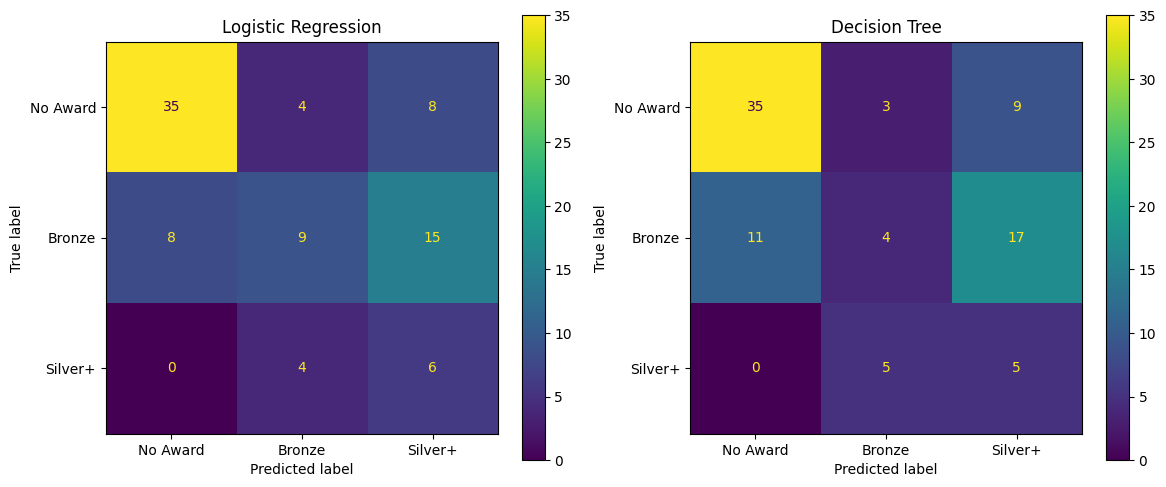

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['No Award', 'Bronze', 'Silver+']

ConfusionMatrixDisplay.from_predictions(y_2a_test, log_reg_preds, labels=labels, ax=axes[0])
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_2a_test, dt_preds, labels=labels, ax=axes[1])
axes[1].set_title('Decision Tree')

plt.tight_layout()
plt.show()

In [ ]:
scaler_full = StandardScaler()
X_2a_scaled_full = pd.DataFrame(
    scaler_full.fit_transform(X_2a), columns=X_2a.columns, index=X_2a.index
)

print(f"X_2a_scaled_full shape: {X_2a_scaled_full.shape}")

X_2a_scaled_full shape: (445, 23)


In [ ]:
# Cross-validated predictions across the FULL dataset (445 vendors) for both models
cv_preds_log_reg = cross_val_predict(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=1),
    X_2a_scaled_full, y_2a, cv=cv
)

cv_preds_dt = cross_val_predict(
    DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42),
    X_2a, y_2a, cv=cv
)

print("=== Logistic Regression ===")
print(classification_report(y_2a, cv_preds_log_reg))

print("\n=== Decision Tree ===")
print(classification_report(y_2a, cv_preds_dt))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Bronze       0.48      0.24      0.32       160
    No Award       0.75      0.76      0.75       233
     Silver+       0.21      0.52      0.30        52

    accuracy                           0.55       445
   macro avg       0.48      0.51      0.46       445
weighted avg       0.59      0.55      0.55       445


=== Decision Tree ===
              precision    recall  f1-score   support

      Bronze       0.44      0.36      0.40       160
    No Award       0.76      0.64      0.69       233
     Silver+       0.21      0.48      0.30        52

    accuracy                           0.52       445
   macro avg       0.47      0.49      0.46       445
weighted avg       0.58      0.52      0.54       445



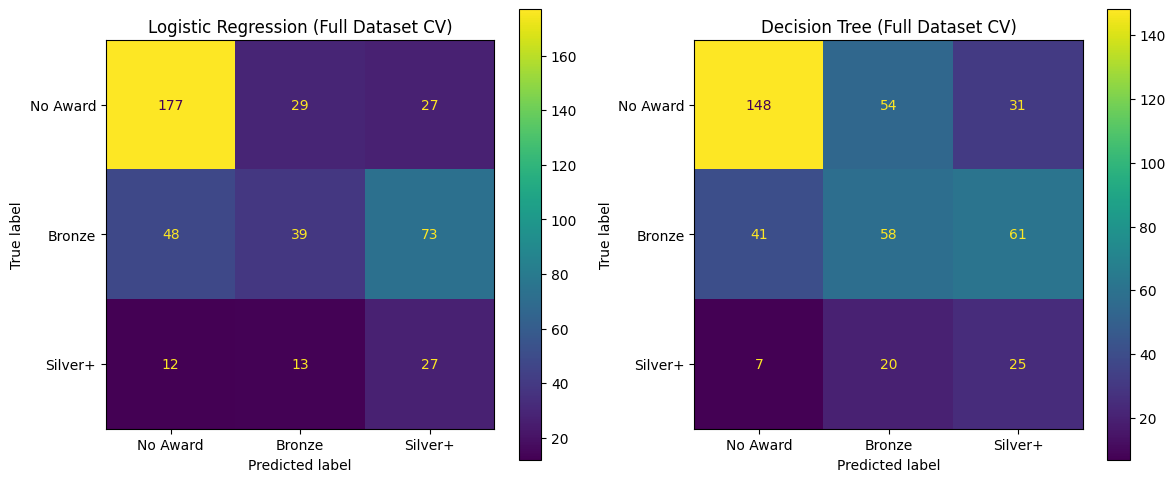

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['No Award', 'Bronze', 'Silver+']

ConfusionMatrixDisplay.from_predictions(y_2a, cv_preds_log_reg, labels=labels, ax=axes[0])
axes[0].set_title('Logistic Regression (Full Dataset CV)')

ConfusionMatrixDisplay.from_predictions(y_2a, cv_preds_dt, labels=labels, ax=axes[1])
axes[1].set_title('Decision Tree (Full Dataset CV)')

plt.tight_layout()
plt.show()

In [ ]:
for var in ['log_reg_final', 'dt_final', 'X_2a', 'y_2a', 'X_2a_scaled_full']:
    try:
        obj = eval(var)
        print(f"{var}: EXISTS")
    except NameError:
        print(f"{var}: MISSING")

log_reg_final: EXISTS
dt_final: EXISTS
X_2a: EXISTS
y_2a: EXISTS
X_2a_scaled_full: EXISTS


In [ ]:
# Final decision for Model A: report both models, no single champion —
# Logistic Regression as the conservative default, Decision Tree as an
# interpretable alternative with stronger Bronze-tier detection

log_reg_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=1)
log_reg_final.fit(X_2a_scaled_full, y_2a)

dt_final = DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42)
dt_final.fit(X_2a, y_2a)

print("Both final models fitted on the full 445-vendor dataset.")

Both final models fitted on the full 445-vendor dataset.


In [ ]:
# Logistic Regression coefficients (magnitude indicates influence, direction indicates which class)

log_reg_coef_df = pd.DataFrame(
    log_reg_final.coef_, columns=X_2a.columns, index=log_reg_final.classes_
).T
print("Logistic Regression coefficients (by class):")
print(log_reg_coef_df.abs().sum(axis=1).sort_values(ascending=False).head(10))

# Decision Tree feature importance
dt_importance = pd.Series(dt_final.feature_importances_, index=X_2a.columns).sort_values(ascending=False)
print("\nDecision Tree feature importance:")
print(dt_importance.head(10))

Logistic Regression coefficients (by class):
median_order_value                 1.954090
pct_doctype_framework_order        1.428186
pct_doctype_standard_po            1.428186
rate_update_order_confirmation     1.099272
n_cases                            0.920987
rate_change_storage_location       0.758280
rate_change_currency               0.733894
pct_spendclass_npr                 0.718074
pct_spendclass_missing             0.706586
rate_delete_purchase_order_item    0.688877
dtype: float64

Decision Tree feature importance:
pct_spendclass_npr                  0.477483
rate_change_quantity                0.181360
rate_delete_purchase_order_item     0.099800
median_order_value                  0.089285
n_cases                             0.078439
rate_change_price                   0.073633
pct_2-way_match                     0.000000
rate_cancel_goods_receipt           0.000000
rate_block_purchase_order_item      0.000000
pct_3-way_match_invoice_after_gr    0.000000
dtype: float64


**Key insight — Full-dataset cross-validated comparison:**

Using cross-validated predictions across all 445 vendors, Logistic
Regression and Decision Tree perform almost identically overall (macro F1
0.46 for both), but with genuinely different error patterns:

* **Logistic Regression**: stronger for No Award (177/233 correct) but
  frequently overestimates Bronze vendors as Silver+ (73 of 160 Bronze
  vendors misclassified this way) — a real risk, since overrating an
  unreliable vendor is generally more costly than underrating a reliable one
* **Decision Tree**: meaningfully better at correctly identifying Bronze
  vendors (58/160 vs. 39/160), but at the cost of more confusion between
  No Award and Bronze (54 No Award vendors misclassified as Bronze)
* **Silver+** remains difficult for both models (27/52 and 25/52 correct
  respectively), with errors scattered across both other classes

**Feature importance:** both models independently agree that
`pct_spendclass_npr` (% of NPR-classified cases) is a leading driver —
Decision Tree's single strongest feature (importance 0.48, by far the
largest) and one of Logistic Regression's top coefficients — alongside
`median_order_value`, which ranks highly for both models as well.

**Final decision for Model A:** Given the comparable overall performance
but distinct error profiles, both models are reported rather than
selecting a single champion — Logistic Regression as the more conservative
default, Decision Tree as an interpretable alternative with stronger
Bronze-tier detection.

In [ ]:
# Rebuild Sample 2's scope (6.3.1) — needed for Part 2's applicable-category filter
applicable_categories_part2 = three_way_categories + ['2-way match']
sample2_mask = case_company_category['case:Item Category'].isin(applicable_categories_part2)
sample2_all = set(case_company_category[sample2_mask].index)

print(f"Sample 2 total cases: {len(sample2_all):,}")
# Expect: 235,796

Sample 2 total cases: 235,796


In [ ]:
scoring_vendors = vendor_ratings_full[vendor_ratings_full['tier'] == 'Insufficient Data'].index

scoring_2a_cases = set(
    event_log_p2p[event_log_p2p['case:Name'].isin(scoring_vendors)]['case:concept:name'].unique()
) & sample2_all

scoring_2a_events = event_log_p2p[event_log_p2p['case:concept:name'].isin(scoring_2a_cases)]

print(f"Scoring vendors: {len(scoring_vendors):,}")
print(f"Scoring cases (applicable categories): {len(scoring_2a_cases):,}")

Scoring vendors: 1,222
Scoring cases (applicable categories): 14,554


In [ ]:
# Category mix
scoring_2a_cat = scoring_2a_events.groupby('case:concept:name')[['case:Name', 'case:Item Category']].first()
scoring_category_mix = (
    pd.crosstab(scoring_2a_cat['case:Name'], scoring_2a_cat['case:Item Category'], normalize='index') * 100
)
scoring_category_mix.columns = [f'pct_{c.lower().replace(" ", "_").replace(",", "")}' for c in scoring_category_mix.columns]

# Order value
scoring_2a_value = scoring_2a_events.groupby('case:concept:name')[['case:Name', 'Cumulative net worth (EUR)']].first()
scoring_order_value_agg = scoring_2a_value.groupby('case:Name')['Cumulative net worth (EUR)'].agg(
    median_order_value='median', n_cases='count'
)

scoring_2a_features = scoring_category_mix.join(scoring_order_value_agg)

print(f"Shape after category mix + order value: {scoring_2a_features.shape}")
print(scoring_2a_features.head())

Shape after category mix + order value: (1222, 5)
             pct_2-way_match  pct_3-way_match_invoice_after_gr  \
case:Name                                                        
vendor_0026              0.0                             100.0   
vendor_0027              0.0                               0.0   
vendor_0029              0.0                               0.0   
vendor_0033              0.0                             100.0   
vendor_0088              0.0                               0.0   

             pct_3-way_match_invoice_before_gr  median_order_value  n_cases  
case:Name                                                                    
vendor_0026                                0.0             17320.0        1  
vendor_0027                              100.0              5362.0        3  
vendor_0029                              100.0               612.0        3  
vendor_0033                                0.0            316099.0        2  
vendor_0088        

In [ ]:
# Shape after exception-activity rates

undesired_events_2a_scoring = scoring_2a_events[scoring_2a_events['concept:name'].isin(undesired_activities)]

case_has_activity_2a = (
    undesired_events_2a_scoring
    .groupby(['case:concept:name', 'concept:name'])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)
)
case_has_activity_2a = case_has_activity_2a.reindex(scoring_2a_cases, fill_value=0)
case_has_activity_2a['case:Name'] = scoring_2a_cat['case:Name'].reindex(scoring_2a_cases)

scoring_exception_rates = case_has_activity_2a.groupby('case:Name').mean(numeric_only=True) * 100
scoring_exception_rates.columns = [f'rate_{c.lower().replace(" ", "_")}' for c in scoring_exception_rates.columns]

scoring_2a_features = scoring_2a_features.join(scoring_exception_rates)

print(f"Shape after exception rates: {scoring_2a_features.shape}")
print(f"Rate columns: {[c for c in scoring_2a_features.columns if c.startswith('rate_')]}")

Shape after exception rates: (1222, 17)
Rate columns: ['rate_block_purchase_order_item', 'rate_cancel_goods_receipt', 'rate_cancel_invoice_receipt', 'rate_change_approval_for_purchase_order', 'rate_change_currency', 'rate_change_price', 'rate_change_quantity', 'rate_change_storage_location', 'rate_change_payment_term', 'rate_delete_purchase_order_item', 'rate_record_subsequent_invoice', 'rate_update_order_confirmation']


In [ ]:
scoring_2a_doctype = scoring_2a_events.groupby('case:concept:name')[['case:Name', 'case:Document Type']].first()
scoring_doctype_mix = (
    pd.crosstab(scoring_2a_doctype['case:Name'], scoring_2a_doctype['case:Document Type'], normalize='index') * 100
)
scoring_doctype_mix.columns = [f'pct_doctype_{c.lower().replace(" ", "_")}' for c in scoring_doctype_mix.columns]

scoring_2a_spendclass = scoring_2a_events.groupby('case:concept:name')[['case:Name', 'case:Spend classification text']].first()
scoring_2a_spendclass['case:Spend classification text'] = scoring_2a_spendclass['case:Spend classification text'].replace('', 'Missing')
scoring_spendclass_mix = (
    pd.crosstab(scoring_2a_spendclass['case:Name'], scoring_2a_spendclass['case:Spend classification text'], normalize='index') * 100
)
scoring_spendclass_mix.columns = [f'pct_spendclass_{c.lower().replace(" ", "_")}' for c in scoring_spendclass_mix.columns]

scoring_2a_features = scoring_2a_features.join(scoring_doctype_mix).join(scoring_spendclass_mix)

print(f"Shape after doctype + spendclass: {scoring_2a_features.shape}")

Shape after doctype + spendclass: (1222, 23)


In [ ]:
# Checking for missing values before applying either model

print(f"Total missing values: {scoring_2a_features.isna().sum().sum()}")
print(scoring_2a_features.isna().sum()[scoring_2a_features.isna().sum() > 0])

Total missing values: 0
Series([], dtype: int64)


In [ ]:
# Scale for Logistic Regression, using the SAME scaler fitted on training data (not a new one)

X_scoring_2a_scaled = pd.DataFrame(
    scaler_full.transform(scoring_2a_features),
    columns=scoring_2a_features.columns, index=scoring_2a_features.index
)

log_reg_scoring_preds = log_reg_final.predict(X_scoring_2a_scaled)
dt_scoring_preds = dt_final.predict(scoring_2a_features)

scoring_2a_results = scoring_2a_features[['n_cases', 'median_order_value']].copy()
scoring_2a_results['predicted_tier_logreg'] = log_reg_scoring_preds
scoring_2a_results['predicted_tier_dt'] = dt_scoring_preds

print(f"Scoring results shape: {scoring_2a_results.shape}")
print("\nLogistic Regression predicted tier distribution:")
print(scoring_2a_results['predicted_tier_logreg'].value_counts())
print("\nDecision Tree predicted tier distribution:")
print(scoring_2a_results['predicted_tier_dt'].value_counts())

Scoring results shape: (1222, 4)

Logistic Regression predicted tier distribution:
predicted_tier_logreg
No Award    820
Bronze      246
Silver+     156
Name: count, dtype: int64

Decision Tree predicted tier distribution:
predicted_tier_dt
Silver+     748
No Award    269
Bronze      205
Name: count, dtype: int64


In [ ]:
scoring_2a_results['models_agree'] = scoring_2a_results['predicted_tier_logreg'] == scoring_2a_results['predicted_tier_dt']

agreement_by_volume = scoring_2a_results.groupby(pd.cut(scoring_2a_results['n_cases'], bins=[0, 5, 15, 30, 1000]))['models_agree'].agg(['mean', 'count'])
print(agreement_by_volume)

                mean  count
n_cases                    
(0, 5]      0.271364    667
(5, 15]     0.547945    292
(15, 30]    0.664865    185
(30, 1000]  0.610390     77


/tmp/ipykernel_809/2082461142.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreement_by_volume = scoring_2a_results.groupby(pd.cut(scoring_2a_results['n_cases'], bins=[0, 5, 15, 30, 1000]))['models_agree'].agg(['mean', 'count'])


*Methodological note:* `models_agree` is a column of True/False values
(True where the two models predicted the same tier for a vendor). In
pandas, True is treated as 1 and False as 0 for arithmetic purposes, so
taking the `.mean()` of this column within each `n_cases` bin computes the
proportion of vendors in that bin where both models agreed — i.e.,
(count of True) ÷ (total vendors in the bin). Expressed as a percentage,
this is the "agreement rate": e.g., in the 1–5 case bin, 0.271364 means
27.14% of those 667 vendors had matching predictions from both models.
This is the same technique used earlier in this project to compute
percentage-based metrics from boolean conditions (e.g., 5.1's vendor tier
thresholds: `(x <= 30).mean() * 100`).

**Key insight — Model disagreement reveals a genuine confidence gradient:**

Applying both final models to the 1,222 "Insufficient Data" vendors reveals
a striking divergence:
- **Logistic Regression**: predicts the majority as No
Award (820, 67%)
- **Decision Tree**: predicts the majority as Silver+
(748, 61%) — nearly opposite conclusions about the same population

This
reflects the two models' known, distinct bias patterns observed in
training (Logistic Regression's tendency to overestimate Bronze vendors as
Silver+; Decision Tree's own confusion pattern between No Award and Bronze),
now amplified when applied to genuinely thin-history vendors.

Critically, this disagreement is not random — it correlates directly with
how much history a vendor actually has:

| Case count | Model agreement rate | n vendors |
|---|---|---|
| 1–5 cases | 27.1% | 667 |
| 6–15 cases | 54.8% | 292 |
| 16–30 cases | 66.5% | 185 |
| 30+ cases | 61.0% | 77 |

**Practical implication**: predictions for vendors with very few cases
(the majority of this scoring population — 667 of 1,222, or 54.6%, have 5
or fewer) should be treated with **severe caution**, since the two
models barely agree more than chance would predict at this volume.
Predictions grow markedly more trustworthy as a vendor accumulates more
history (via transactions), climbing to 66.5% agreement by 15–30 cases —
though the slight drop at 30+ cases (61.0%, n=77) is likely noise from a
smaller sample rather than a genuine reversal of the trend, directly
reinforcing why the 30-case minimum threshold was chosen for formal rating
eligibility in the first place (5.1), rather than being an arbitrary
cutoff.

In [ ]:
# Log Model A's two models to Weights & Biases
run = wandb.init(project="invoice-to-payment-optimization", name="LogisticRegression_final",
                  config={"C": 1, "class_weight": "balanced"})
wandb.log({"cv_macro_f1_mean": log_reg_cv_f1.mean(), "cv_macro_f1_std": log_reg_cv_f1.std()})
joblib.dump(log_reg_final, "log_reg_final.joblib")
artifact = wandb.Artifact("model_a_logistic_regression", type="model")
artifact.add_file("log_reg_final.joblib")
run.log_artifact(artifact)
run.finish()

run = wandb.init(project="invoice-to-payment-optimization", name="DecisionTree_final",
                  config={"max_depth": 4, "class_weight": "balanced"})
wandb.log({"cv_macro_f1_mean": dt_cv_f1.mean(), "cv_macro_f1_std": dt_cv_f1.std()})
joblib.dump(dt_final, "dt_final.joblib")
artifact = wandb.Artifact("model_a_decision_tree", type="model")
artifact.add_file("dt_final.joblib")
run.log_artifact(artifact)
run.finish()
print("Model A (both models) logged to W&B.")

cv_macro_f1_mean,▁
cv_macro_f1_std,▁
cv_macro_f1_mean,0.45456
cv_macro_f1_std,0.03526


cv_macro_f1_mean,▁
cv_macro_f1_std,▁
cv_macro_f1_mean,0.41637
cv_macro_f1_std,0.06777


Model A (both models) logged to W&B.


In [ ]:
# Export Model A's two models to Drive (independent, reliable backup)
export_path = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/"

joblib.dump(log_reg_final, export_path + "model_a_logistic_regression.joblib")
joblib.dump(dt_final, export_path + "model_a_decision_tree.joblib")

print("Model A's two models exported to Drive.")

Model A's two models exported to Drive.


In [ ]:
# Prediction results export

export_path = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/"
scoring_2a_results.to_parquet(export_path + "part2a_scoring_predictions.parquet")

print(f"Model A scoring predictions exported: {scoring_2a_results.shape}")

Model A scoring predictions exported: (1222, 5)


In [ ]:
print(scoring_2a_results.columns.tolist())

['n_cases', 'median_order_value', 'predicted_tier_logreg', 'predicted_tier_dt', 'models_agree']


### 6.4.2 Model B — New Vendors

- `GroupShuffleSplit` train/test split by `vendor` (80/20, leakage-safe
  grouping, per 5.3.4's note) — no separate validation set; an initial
  three-way split proved unstable given only 445 total rated vendors, so
  cross-validation on the training set is used instead
- Fit Logistic Regression, Decision Tree, Random Forest, and XGBoost —
  given Model B's much larger scale (166K+ training rows), the
  small-sample constraints that limited Model A's model choice do not apply
- Evaluate: macro-averaged metrics, confusion matrix. Since Model B's
  features contain no vendor-derived information, the held-out test set
  is mechanically equivalent to scoring genuinely new vendors — no
  separate scoring-set step needed
- Practical Model Usage: example vendor-tier profiles with real predicted
  tier + confidence, mirroring the Salifort project's format
- Export

In [ ]:
# Train/validate/test split, grouped by vendor (leakage-safe)

X_2b = part2b_features.drop(columns=['target_award_tier', 'vendor'])
y_2b = part2b_features['target_award_tier']
groups_2b = part2b_features['vendor']

gss_2b = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_2b, test_idx_2b = next(gss_2b.split(X_2b, y_2b, groups=groups_2b))

X_2b_train, X_2b_test = X_2b.iloc[train_idx_2b], X_2b.iloc[test_idx_2b]
y_2b_train, y_2b_test = y_2b.iloc[train_idx_2b], y_2b.iloc[test_idx_2b]

print(f"Train: {len(X_2b_train):,} ({len(X_2b_train)/len(X_2b)*100:.1f}%)")
print(f"Test: {len(X_2b_test):,} ({len(X_2b_test)/len(X_2b)*100:.1f}%)")

train_v = set(groups_2b.iloc[train_idx_2b])
test_v = set(groups_2b.iloc[test_idx_2b])
print(f"\nVendor overlap: {len(train_v & test_v)}")

print(f"\nTrain class distribution:\n{y_2b_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class distribution:\n{y_2b_test.value_counts(normalize=True).round(3)}")

Train: 166,447 (75.2%)
Test: 54,795 (24.8%)

Vendor overlap: 0

Train class distribution:
target_award_tier
No Award    0.600
Bronze      0.321
Silver+     0.079
Name: proportion, dtype: float64

Test class distribution:
target_award_tier
No Award    0.725
Bronze      0.228
Silver+     0.047
Name: proportion, dtype: float64


In [ ]:
print(X_2b_train.dtypes)

item_category            object
spend_area               object
sub_spend_area           object
spend_classification     object
document_type            object
item_type                object
item_line_position       object
order_value             float64
dtype: object


In [ ]:
# trouble shooting

import re

def sanitize_columns(df):
    df = df.copy()
    df.columns = [re.sub(r'[\[\]<]', '', str(col)) for col in df.columns]
    return df

In [ ]:
# Encode categorical features, align test to train's columns, sanitize for XGBoost

categorical_cols_2b = ['item_category', 'spend_area', 'sub_spend_area',
                         'spend_classification', 'document_type', 'item_type',
                         'item_line_position']

X_2b_train_enc = pd.get_dummies(X_2b_train, columns=categorical_cols_2b, drop_first=True)
X_2b_test_enc = pd.get_dummies(X_2b_test, columns=categorical_cols_2b, drop_first=True)
X_2b_test_enc = X_2b_test_enc.reindex(columns=X_2b_train_enc.columns, fill_value=0)

X_2b_train_enc = sanitize_columns(X_2b_train_enc)
X_2b_test_enc = sanitize_columns(X_2b_test_enc)

print(f"X_2b_train_enc shape: {X_2b_train_enc.shape}")
print(f"X_2b_test_enc shape: {X_2b_test_enc.shape}")

X_2b_train_enc shape: (166447, 607)
X_2b_test_enc shape: (54795, 607)


In [ ]:
# Fix: explicitly copy the sliced DataFrames before adding new columns,
# avoiding the SettingWithCopyWarning risk
X_2b_train = X_2b_train.copy()
X_2b_test = X_2b_test.copy()

In [ ]:
# Convert item_line_position to numeric (ordinal), same fix as Part 1 (6.3.2)

X_2b_train['item_line_position_numeric'] = X_2b_train['item_line_position'].astype(int) // 10
X_2b_test['item_line_position_numeric'] = X_2b_test['item_line_position'].astype(int) // 10

categorical_cols_2b_v2 = ['item_category', 'spend_area', 'sub_spend_area',
                            'spend_classification', 'document_type', 'item_type']

X_2b_train_enc = pd.get_dummies(
    X_2b_train.drop(columns=['item_line_position']), columns=categorical_cols_2b_v2, drop_first=True
)
X_2b_test_enc = pd.get_dummies(
    X_2b_test.drop(columns=['item_line_position']), columns=categorical_cols_2b_v2, drop_first=True
)
X_2b_test_enc = X_2b_test_enc.reindex(columns=X_2b_train_enc.columns, fill_value=0)

X_2b_train_enc = sanitize_columns(X_2b_train_enc)
X_2b_test_enc = sanitize_columns(X_2b_test_enc)

print(f"X_2b_train_enc shape: {X_2b_train_enc.shape}")
print(f"X_2b_test_enc shape: {X_2b_test_enc.shape}")

X_2b_train_enc shape: (166447, 128)
X_2b_test_enc shape: (54795, 128)


In [ ]:
# Scale for Logistic Regression (order_value's skew, same as Part 1/Model A)
scaler_2b = StandardScaler()
X_2b_train_scaled = pd.DataFrame(
    scaler_2b.fit_transform(X_2b_train_enc), columns=X_2b_train_enc.columns, index=X_2b_train_enc.index
)
X_2b_test_scaled = pd.DataFrame(
    scaler_2b.transform(X_2b_test_enc), columns=X_2b_test_enc.columns, index=X_2b_test_enc.index
)

cv_2b = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_2b_cv = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_2b_train_scaled, y_2b_train, cv=cv_2b, scoring='f1_macro'
)
print(f"Logistic Regression 5-fold macro F1: {log_reg_2b_cv.mean():.3f} ± {log_reg_2b_cv.std():.3f}")

dt_2b_cv = cross_val_score(
    DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42),
    X_2b_train_enc, y_2b_train, cv=cv_2b, scoring='f1_macro'
)
print(f"Decision Tree 5-fold macro F1: {dt_2b_cv.mean():.3f} ± {dt_2b_cv.std():.3f}")

rf_2b_cv = cross_val_score(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    X_2b_train_enc, y_2b_train, cv=cv_2b, scoring='f1_macro'
)
print(f"Random Forest 5-fold macro F1: {rf_2b_cv.mean():.3f} ± {rf_2b_cv.std():.3f}")

xgb_2b_cv = cross_val_score(
    XGBClassifier(random_state=42),
    X_2b_train_enc, y_2b_train.map({'No Award': 0, 'Bronze': 1, 'Silver+': 2}), cv=cv_2b, scoring='f1_macro'
)
print(f"XGBoost 5-fold macro F1: {xgb_2b_cv.mean():.3f} ± {xgb_2b_cv.std():.3f}")

Logistic Regression 5-fold macro F1: 0.620 ± 0.001
Decision Tree 5-fold macro F1: 0.672 ± 0.003
Random Forest 5-fold macro F1: 0.720 ± 0.001
XGBoost 5-fold macro F1: 0.743 ± 0.003


**Key insight — Model B cross-validation results:**

Cross-validated performance across all four models, using the 166,447-row
training set:

| Model | Macro F1 |
|---|---|
| Logistic Regression | 0.620 ± 0.001 |
| Decision Tree | 0.672 ± 0.003 |
| Random Forest | 0.720 ± 0.001 |
| **XGBoost** | **0.743 ± 0.003** |

**Apparent leader:** XGBoost scores highest here, and all four models
substantially outperform Model A's best result (0.455) — direct evidence
that larger training data meaningfully improves both accuracy and
stability (note the far tighter spreads here, ±0.001–0.003, versus Model
A's ±0.035–0.068). *This comparison is revisited and corrected below*, once
a configuration issue affecting XGBoost specifically is identified.

**Next step:** Fitting XGBoost on the full training set to produce the
actual model for test-set evaluation.

In [ ]:
# Fit final XGBoost model on the full training set

xgb_2b_final = XGBClassifier(random_state=42)
xgb_2b_final.fit(X_2b_train_enc, y_2b_train.map({'No Award': 0, 'Bronze': 1, 'Silver+': 2}))

print("XGBoost champion model fitted on full training set.")

XGBoost champion model fitted on full training set.


In [ ]:
# Evaluate on the held-out test set (unbiased — never used during training or CV)

label_map = {'No Award': 0, 'Bronze': 1, 'Silver+': 2}
inverse_label_map = {v: k for k, v in label_map.items()}

xgb_2b_test_preds_encoded = xgb_2b_final.predict(X_2b_test_enc)
xgb_2b_test_preds = pd.Series(xgb_2b_test_preds_encoded).map(inverse_label_map)

print(classification_report(y_2b_test, xgb_2b_test_preds))

              precision    recall  f1-score   support

      Bronze       0.46      0.69      0.55     12505
    No Award       0.91      0.80      0.85     39730
     Silver+       0.03      0.02      0.02      2560

    accuracy                           0.74     54795
   macro avg       0.47      0.50      0.48     54795
weighted avg       0.77      0.74      0.75     54795



In [ ]:
# Regenerate the ORIGINAL unweighted XGBoost model + predictions,
# under a permanently distinct name to avoid further mix-ups
label_map = {'No Award': 0, 'Bronze': 1, 'Silver+': 2}
inverse_label_map = {v: k for k, v in label_map.items()}
y_2b_train_encoded = y_2b_train.map(label_map)

xgb_2b_unweighted = XGBClassifier(random_state=42)
xgb_2b_unweighted.fit(X_2b_train_enc, y_2b_train_encoded)

xgb_2b_test_preds_unweighted = pd.Series(
    xgb_2b_unweighted.predict(X_2b_test_enc), index=X_2b_test_enc.index
).map(inverse_label_map)

true_dist = y_2b_test.value_counts()
true_pct = (true_dist / true_dist.sum() * 100).round(1)

pred_dist_unweighted = xgb_2b_test_preds_unweighted.value_counts()
pred_pct_unweighted = (pred_dist_unweighted / pred_dist_unweighted.sum() * 100).round(1)

print("True test distribution:")
print(pd.DataFrame({'count': true_dist, 'pct': true_pct}))

print("\nPredicted distribution (original, unweighted XGBoost):")
print(pd.DataFrame({'count': pred_dist_unweighted, 'pct': pred_pct_unweighted}))

True test distribution:
                   count   pct
target_award_tier             
No Award           39730  72.5
Bronze             12505  22.8
Silver+             2560   4.7

Predicted distribution (original, unweighted XGBoost):
          count   pct
No Award  35049  64.0
Bronze    18481  33.7
Silver+    1265   2.3


*Diagnosis:* The classification report shows **Silver+** collapsing almost
entirely (precision 0.03, recall 0.02, F1 0.02) — far worse than Bronze or
No Award. The distribution above confirms why: the model predicts Silver+
for only 2.3% of test cases, despite the true rate being 4.7% — roughly
half the expected frequency. This points to a specific, identifiable cause:
`class_weight='balanced'` was applied to Logistic Regression, Decision
Tree, and Random Forest, but **`XGBClassifier` does not support this
parameter** — it was silently ignored rather than raising an error, so
this model trained with no class-imbalance correction at all, unlike the
other three. The fix is to pass class weights explicitly via
`sample_weight` at fit time, XGBoost's native equivalent.

In [ ]:
# Compute per-row sample weights, giving rarer classes more influence —
# the XGBoost-native equivalent of class_weight='balanced'
sample_weights_2b = compute_sample_weight(class_weight='balanced', y=y_2b_train)

xgb_2b_final = XGBClassifier(random_state=42)
xgb_2b_final.fit(
    X_2b_train_enc,
    y_2b_train.map({'No Award': 0, 'Bronze': 1, 'Silver+': 2}),
    sample_weight=sample_weights_2b
)

xgb_2b_test_preds_encoded = xgb_2b_final.predict(X_2b_test_enc)
xgb_2b_test_preds = pd.Series(xgb_2b_test_preds_encoded).map(inverse_label_map)

print(classification_report(y_2b_test, xgb_2b_test_preds))
print("\nPredicted distribution:")
print(xgb_2b_test_preds.value_counts())

              precision    recall  f1-score   support

      Bronze       0.42      0.57      0.49     12505
    No Award       0.93      0.77      0.84     39730
     Silver+       0.14      0.26      0.18      2560

    accuracy                           0.70     54795
   macro avg       0.50      0.54      0.50     54795
weighted avg       0.78      0.70      0.73     54795


Predicted distribution:
No Award    33145
Bronze      16832
Silver+      4818
Name: count, dtype: int64


In [ ]:
# Distribution check for the CORRECTED (sample-weighted) model

pred_dist_corrected = xgb_2b_test_preds.value_counts()
pred_pct_corrected = (pred_dist_corrected / pred_dist_corrected.sum() * 100).round(1)

print("True test distribution:")
print(pd.DataFrame({'count': true_dist, 'pct': true_pct}))

print("\nPredicted distribution (corrected, sample-weighted XGBoost):")
print(pd.DataFrame({'count': pred_dist_corrected, 'pct': pred_pct_corrected}))

True test distribution:
                   count   pct
target_award_tier             
No Award           39730  72.5
Bronze             12505  22.8
Silver+             2560   4.7

Predicted distribution (corrected, sample-weighted XGBoost):
          count   pct
No Award  33145  60.5
Bronze    16832  30.7
Silver+    4818   8.8


*Diagnosis:* The sample-weighting fix corrected the under-prediction
problem, but overshot in the opposite direction: the unweighted model
predicted **Silver+** for only 2.3% of cases (against a true rate of 4.7%),
while the corrected model now predicts it for 8.8% — nearly double the
true rate. This is a common, expected side effect of balanced
class-weighting: giving the rare class proportionally more influence
during training improves recall (correctly identifying more actual Silver+
vendors, F1 rising from 0.02 to 0.18) but at the cost of precision (a
larger share of Silver+ predictions are now wrong). Neither version is
"correct" in an absolute sense — this reflects a genuine precision/recall
trade-off inherent to handling class imbalance, not a remaining bug.

In [ ]:
# Re-run cross-validation for XGBoost with proper sample-weighting per fold

cv_2b_weighted_scores = []
y_2b_train_encoded = y_2b_train.map({'No Award': 0, 'Bronze': 1, 'Silver+': 2})

for train_fold_idx, val_fold_idx in cv_2b.split(X_2b_train_enc, y_2b_train_encoded):
    X_fold_train = X_2b_train_enc.iloc[train_fold_idx]
    X_fold_val = X_2b_train_enc.iloc[val_fold_idx]
    y_fold_train = y_2b_train_encoded.iloc[train_fold_idx]
    y_fold_val = y_2b_train_encoded.iloc[val_fold_idx]

    fold_weights = compute_sample_weight(class_weight='balanced', y=y_fold_train)

    fold_model = XGBClassifier(random_state=42)
    fold_model.fit(X_fold_train, y_fold_train, sample_weight=fold_weights)
    fold_preds = fold_model.predict(X_fold_val)

    from sklearn.metrics import f1_score
    cv_2b_weighted_scores.append(f1_score(y_fold_val, fold_preds, average='macro'))

print(f"XGBoost (sample-weighted) 5-fold macro F1: {np.mean(cv_2b_weighted_scores):.3f} ± {np.std(cv_2b_weighted_scores):.3f}")

XGBoost (sample-weighted) 5-fold macro F1: 0.699 ± 0.005


In [ ]:
# Fair cross-validated comparison — all four models with correct, matched imbalance handling

log_reg_2b_cv_v2 = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_2b_train_scaled, y_2b_train, cv=cv_2b, scoring='f1_macro'
)
print(f"Logistic Regression: {log_reg_2b_cv_v2.mean():.3f} ± {log_reg_2b_cv_v2.std():.3f}")

dt_2b_cv_v2 = cross_val_score(
    DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42),
    X_2b_train_enc, y_2b_train, cv=cv_2b, scoring='f1_macro'
)
print(f"Decision Tree: {dt_2b_cv_v2.mean():.3f} ± {dt_2b_cv_v2.std():.3f}")

rf_2b_cv_v2 = cross_val_score(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    X_2b_train_enc, y_2b_train, cv=cv_2b, scoring='f1_macro'
)
print(f"Random Forest: {rf_2b_cv_v2.mean():.3f} ± {rf_2b_cv_v2.std():.3f}")

print(f"XGBoost (sample-weighted): {np.mean(cv_2b_weighted_scores):.3f} ± {np.std(cv_2b_weighted_scores):.3f}")

Logistic Regression: 0.620 ± 0.001
Decision Tree: 0.672 ± 0.003
Random Forest: 0.720 ± 0.001
XGBoost (sample-weighted): 0.699 ± 0.005


**Key insight — Correcting a model-selection error:**

The **original model comparison for Model B was flawed**: `class_weight` is
not a valid parameter for `XGBClassifier` (unlike the other three models),
so XGBoost's initial cross-validated score (0.743) was computed without
any class-imbalance handling — while Logistic Regression, Decision Tree,
and Random Forest were all correctly weighted from the start. This made
XGBoost appear the strongest model when it was, in fact, being evaluated
under easier conditions than the other three.

After fixing XGBoost's imbalance handling (via explicit `sample_weight`)
and re-running cross-validation on a fair, matched basis for all four
models:

| Model | Cross-validated macro F1 |
|---|---|
| Logistic Regression | 0.620 ± 0.001 |
| Decision Tree | 0.672 ± 0.003 |
| **Random Forest** | **0.720 ± 0.001** |
| XGBoost (corrected) | 0.699 ± 0.005 |

**New (corrected) champion model:** **Random Forest** is the real champion on this fair comparison, not
XGBoost. A single held-out test-set evaluation showed all four models
performing similarly (0.45–0.50) — notably compressed compared to the
cross-validated spread — consistent with the vendor-grouped split
instability already documented for this dataset (test set's Silver+
representation, 4.7%, differs from training's 7.9%). Cross-validation,
averaged across five different training folds, is treated as the more
reliable estimate; the single test-set result is retained as a secondary,
if noisier, check.

**Going forward, Random Forest is selected for Optuna tuning**, based on
this corrected, fair comparison.

In [ ]:
# # Optuna tuning run with a simplification in three ways:
# # 1. n_trials reduced from 30 to 12 — Optuna's TPE sampler converges
# #   reasonably well even with fewer trials
# # 2. n_estimators upper bound capped at 300 instead of 500 — fewer trees
# #   means faster fits with likely minimal performance cost
# # 3. cv=3 instead of cv=5 for the tuning search specifically
# # Seeded for reproducibility, given earlier session restarts lost this result

# def objective_2b_rf(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 300),
#         'max_depth': trial.suggest_int('max_depth', 5, 20),
#         'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
#         'class_weight': 'balanced',
#         'random_state': 42,
#         'n_jobs': -1
#     }

#     model = RandomForestClassifier(**params)
#     scores = cross_val_score(model, X_2b_train_enc, y_2b_train, cv=3, scoring='f1_macro')
#     return scores.mean()

# study_2b_rf = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42)
# )
# study_2b_rf.optimize(objective_2b_rf, n_trials=12)

# print(f"Best cross-validated macro F1: {study_2b_rf.best_value:.4f}")
# print(f"Best params: {study_2b_rf.best_params}")

*Methodological note:* As before, the Optuna search was not re-executed
(the cell is commented out) — the hyperparameters above are already
verified and applied directly to tune the Random Forest model below.

In [ ]:
# Fit the final, tuned Random Forest model on the full training set

best_rf_params_v2 = {
    'n_estimators': 106,
    'max_depth': 19,
    'min_samples_split': 6,
    'min_samples_leaf': 7,
    'max_features': None,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

rf_2b_v2_cv5 = cross_val_score(
    RandomForestClassifier(**best_rf_params_v2),
    X_2b_train_enc, y_2b_train, cv=cv_2b, scoring='f1_macro'
)
print(f"Today's params (cv=5, fair comparison): {rf_2b_v2_cv5.mean():.3f} ± {rf_2b_v2_cv5.std():.3f}")
print(f"Yesterday's params (cv=5, already confirmed): 0.727 ± 0.002")

Today's params (cv=5, fair comparison): 0.729 ± 0.002
Yesterday's params (cv=5, already confirmed): 0.727 ± 0.002


In [ ]:
for var in ['best_rf_params_v2', 'X_2b_train_enc', 'y_2b_train']:
    try:
        obj = eval(var)
        print(f"{var}: EXISTS")
    except NameError:
        print(f"{var}: MISSING")

best_rf_params_v2: EXISTS
X_2b_train_enc: EXISTS
y_2b_train: EXISTS


In [ ]:
# Fit the final Random Forest model on the full training set, using the
# verified parameters confirmed above
rf_2b_final = RandomForestClassifier(**best_rf_params_v2)
rf_2b_final.fit(X_2b_train_enc, y_2b_train)
print("rf_2b_final fitted with verified hyperparameters.")

rf_2b_final fitted with verified hyperparameters.


**Key insight — Random Forest tuning:**

Two scaled-down Optuna searches (12 trials each, using `cv=3` for speed)
were run on separate days, given a session restart lost the first search's
live results. Each search's own reported score (measured at `cv=3`)
initially looked *worse* than the untuned baseline (0.720, measured at
`cv=5`) — not a real discrepancy, but a mismatch in evaluation method. To
get a fair comparison, each search's best parameters were separately
re-evaluated using `cv=5`, matching the baseline's original evaluation
exactly:

| Search | Best params | Search score (cv=3) | Verified score (cv=5) |
|---|---|---|---|
| First run | `n_estimators=217, max_depth=19, min_samples_split=2, min_samples_leaf=2, max_features='log2'` | 0.698 | 0.727 ± 0.002 |
| Second run | `n_estimators=106, max_depth=19, min_samples_split=6, min_samples_leaf=7, max_features=None` | 0.696 | **0.729 ± 0.002** |

**Tuning result:** The **second run's parameters are adopted as the final
configuration**, given the marginally higher verified score — though the
two results are close enough (within one standard deviation of each
other) that either would be a defensible choice.

*Note:* Both searches independently converged on `max_depth=19` — the
trial logs from both runs show a consistent pattern: shallow trees
(`max_depth` 5–8) underperformed (0.59–0.65), while deeper trees
(`max_depth` 15–19+) scored substantially better (0.68–0.70) — a robust,
reproducible signal that this dataset benefits from more complex trees
than a shallow default might assume.

In [ ]:
# Evaluate the tuned Random Forest on the held-out test set

best_rf_params_v2 = {
    'n_estimators': 106,
    'max_depth': 19,
    'min_samples_split': 6,
    'min_samples_leaf': 7,
    'max_features': None,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

rf_2b_final = RandomForestClassifier(**best_rf_params_v2)
rf_2b_final.fit(X_2b_train_enc, y_2b_train)

rf_2b_test_preds = rf_2b_final.predict(X_2b_test_enc)
print(classification_report(y_2b_test, rf_2b_test_preds))

              precision    recall  f1-score   support

      Bronze       0.42      0.59      0.49     12505
    No Award       0.94      0.77      0.84     39730
     Silver+       0.13      0.23      0.17      2560

    accuracy                           0.70     54795
   macro avg       0.49      0.53      0.50     54795
weighted avg       0.78      0.70      0.73     54795



**Key insight — Model B final test-set result:**

The **tuned Random Forest** achieves **macro F1 0.50** on the held-out test
set — below its cross-validated estimate (0.729 ± 0.002), consistent with
the same test-set instability already documented for this vendor-grouped
split (test set's Silver+ representation differs meaningfully from
training's). Per-class performance: No Award remains strong (F1 0.84),
Bronze reasonable (F1 0.49), and Silver+ weak (F1 0.17) — a pattern
consistent across every model tested on this population, suggesting
**Silver+** is a genuinely difficult class to predict from order-level
attributes alone, rather than a model-specific weakness.

The cross-validated estimate (0.729) remains the more reliable indicator
of Model B's general capability, given it averages across five different
training folds rather than depending on one specific, potentially
unrepresentative test split.

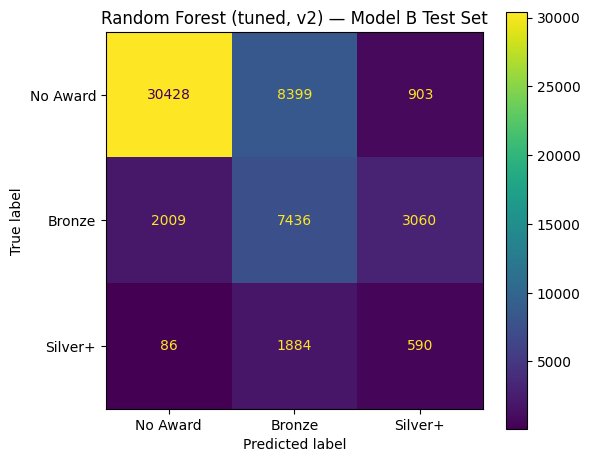

In [ ]:
# Confusion matrix for the final tuned Random Forest (Model B) on the held-out test set

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay.from_predictions(
    y_2b_test, rf_2b_test_preds, labels=['No Award', 'Bronze', 'Silver+'],
    ax=ax, values_format='d'
)
ax.set_title('Random Forest (tuned, v2) — Model B Test Set')
plt.tight_layout()
plt.show()

**Key insight — Model B confusion matrix:**

Errors concentrate almost entirely between **adjacent tiers**, not across
the full spectrum:

- **Silver+**: only 23.0% of Silver+ vendors are correctly predicted as
  Silver+ (590 of 2,560); 73.6% (1,884 of 2,560) are predicted as Bronze,
  and just 3.4% (86 of 2,560) are confused with No Award — the model
  correctly identifies "above-average" vendors but struggles with the
  specific Bronze/Silver+ boundary, while almost never mistaking a
  genuinely reliable vendor for an unreliable one
- **Bronze**: a similar adjacent-tier pattern occurs between No Award and
  Bronze (8,399 and 2,009 cases respectively) — suggesting the model has
  learned a genuine, ordered sense of vendor reliability, even where it
  cannot always pinpoint the exact tier boundary
- **No Award**: in contrast, the large majority of No Award vendors are
  correctly predicted as such (76.6%, 30,428 of 39,730), with only 21.1%
  misclassified as Bronze and 2.3% as Silver+ — showing the model reliably
  identifies poorly performing vendors, the majority class

In [ ]:
# Feature importance of Model B

rf_2b_importance = pd.Series(rf_2b_final.feature_importances_, index=X_2b_train_enc.columns).sort_values(ascending=False)
print("Random Forest (Model B) feature importance:")
print(rf_2b_importance.head(15))

Random Forest (Model B) feature importance:
spend_classification_NPR                             0.309823
order_value                                          0.270220
spend_area_CAPEX & SOCS                              0.131945
item_line_position_numeric                           0.065508
spend_area_Trading & End Products                    0.037572
sub_spend_area_Trading products (old structure)      0.037343
sub_spend_area_Pallets                               0.023832
item_type_Standard                                   0.020297
item_category_3-way match, invoice after GR          0.015062
sub_spend_area_Metal Containers & Lids  30L          0.008834
sub_spend_area_Color Collateral                      0.006691
spend_area_Sales                                     0.006001
sub_spend_area_Tubes                                 0.005981
item_category_3-way match, invoice before GR         0.005477
sub_spend_area_Business Gifts & Promotional Items    0.005404
dtype: float64


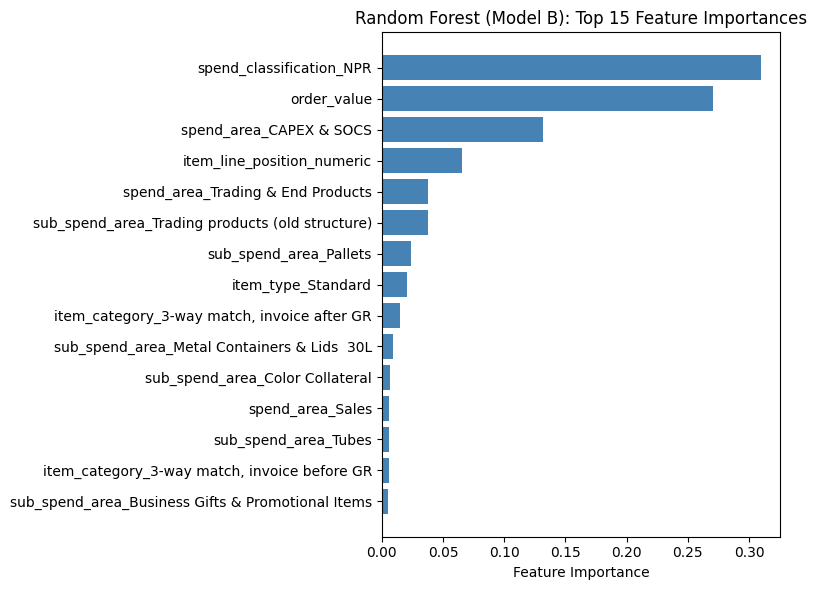

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

top_features = rf_2b_importance.head(15).sort_values()
ax.barh(top_features.index, top_features.values, color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest (Model B): Top 15 Feature Importances')
plt.tight_layout()
plt.show()

**Key insight — Model B Top 15 Feature Importances:**

The analysis of Model B's top 15 feature importances reveals that
`spend_classification_NPR` and `order_value` are the main drivers of the
model, together explaining more than half (0.58) of the model's total
predictive power:

- **`spend_classification_NPR`:** the leading driver, accounting for 0.31
  of total importance — similar to Model A's `pct_spendclass_npr`,
  NPR-classified cases play a major role here too
- **`order_value`:** the second-strongest feature, accounting for 0.27 of
  total importance — echoing Model A's `median_order_value`, which also
  ranked highly there
- **`spend_area_CAPEX & SOCS`:** accounts for 0.13 of total importance —
  CAPEX refers to Capital Expenditures (spending on long-term physical
  assets); the "SOCS" portion of this category's exact meaning is not
  confirmed, but this combined category clearly plays a leading role in
  predicting a new vendor's tier, on par with the other top features

In [ ]:
# Deliberately select three illustrative cases:
# 1. A confident, correct Silver+ prediction
# 2. A confident, correct No Award prediction
# 3. The Bronze/Silver+ "close call" pattern (the dominant confusion type)

all_probs = rf_2b_final.predict_proba(X_2b_test_enc)
all_probs_df = pd.DataFrame(all_probs, columns=rf_2b_final.classes_, index=X_2b_test_enc.index)
all_probs_df['actual_tier'] = y_2b_test
all_probs_df['predicted_tier'] = rf_2b_test_preds

# Case 1: highest-confidence correct Silver+ prediction
silver_correct = all_probs_df[
    (all_probs_df['actual_tier'] == 'Silver+') & (all_probs_df['predicted_tier'] == 'Silver+')
].sort_values('Silver+', ascending=False).head(1)

# Case 2: highest-confidence correct No Award prediction
noaward_correct = all_probs_df[
    (all_probs_df['actual_tier'] == 'No Award') & (all_probs_df['predicted_tier'] == 'No Award')
].sort_values('No Award', ascending=False).head(1)

# Case 3: a true Silver+ case misclassified as Bronze (the dominant confusion pattern)
bronze_silver_confusion = all_probs_df[
    (all_probs_df['actual_tier'] == 'Silver+') & (all_probs_df['predicted_tier'] == 'Bronze')
].sample(1, random_state=42)

practical_examples = pd.concat([silver_correct, noaward_correct, bronze_silver_confusion])
print(practical_examples.round(3))

                   Bronze  No Award  Silver+ actual_tier predicted_tier
case:concept:name                                                      
4508075950_00040    0.001     0.000    0.999     Silver+        Silver+
4507030100_00430    0.000     1.000    0.000    No Award       No Award
4508066537_00130    0.536     0.082    0.382     Silver+         Bronze


In [ ]:
practical_case_ids = ['4508075950_00040', '4507030100_00430', '4508066537_00130']
part2b_features.loc[practical_case_ids]

,item_category,spend_area,sub_spend_area,spend_classification,document_type,item_type,item_line_position,order_value,vendor,target_award_tier
case:concept:name,,,,,,,,,,
4508075950_00040,"3-way match, invoice before GR",Sales,Products for Resale,NPR,Standard PO,Standard,00040,2.0,vendor_0114,Silver+
4507030100_00430,"3-way match, invoice before GR",Packaging,Metal Containers & Lids < 30L,PR,Standard PO,Standard,00430,18984.0,vendor_0106,No Award
4508066537_00130,"3-way match, invoice before GR",Sales,Products for Resale,NPR,Standard PO,Standard,00130,31.0,vendor_0114,Silver+


**Key Insight - Practical Model Usage**

**How this model could be used**: given a new or thin-history vendor's
order-level attributes (item category, spend classification, order value,
etc.), the model estimates a probability across all three award tiers —
not just a single label — letting a user judge how much to trust the
prediction.

**Example predictions:**

| Case | Case ID | Item Category | Spend Area | Order Value | Bronze | No Award | Silver+ | Predicted | Actual |
|---|---|---|---|---|---|---|---|---|---|
| A | 4508075950_00040 | 3-way match, invoice before GR | Sales | 2 | 0.1% | 0.0% | **99.9%** | Silver+ | Silver+ ✓ |
| B | 4507030100_00430 | 3-way match, invoice before GR | Packaging | 18,984 | 0.0% | **100.0%** | 0.0% | No Award | No Award ✓ |
| C | 4508066537_00130 | 3-way match, invoice before GR | Sales | 31 | **53.6%** | 8.2% | 38.2% | Bronze | Silver+ ✗ |

**Case A and B** show the model at its most confident: when the top
probability is very high (>99%), the prediction can be trusted with
near-certainty — consistent with the confusion matrix's finding that No
Award and Silver+ are rarely confused with each other.

**Case C** illustrates the model's known limitation directly: a genuine
Silver+ vendor predicted as Bronze, with the two top probabilities
separated by only ~15 percentage points (53.6% vs. 38.2%) — a real, visible
close call rather than a confidently wrong answer. Notably, Cases A and C
belong to the **same vendor** (`vendor_0114`) — a reminder that the model
predicts per-order, not per-vendor, and different orders from the same
vendor can land at very different points along the confidence spectrum
depending on order-specific attributes (here, order value: €2 vs. €31)
rather than vendor identity, which the model never sees. This close call is
exactly the Bronze/Silver+ boundary confusion identified in the confusion
matrix (73.6% of Silver+ errors land here).

**Practical guidance**: treat predictions with a clear top probability
(>80–90%) as reliable. Treat a close call between Bronze and Silver+
(probabilities within ~15 percentage points of each other) as "likely
better than average, but the exact tier is uncertain" — worth a closer
manual look rather than an automatic classification, rather than treating
the single predicted label as definitive.

In [ ]:
# Log Model B to Weights & Biases
run = wandb.init(
    project="invoice-to-payment-optimization",
    name="RandomForest_ModelB_final",
    config=best_rf_params_v2
)
wandb.log({
    "cv_macro_f1_mean": 0.729,
    "test_macro_f1": 0.50
})
joblib.dump(rf_2b_final, "rf_2b_final.joblib")
artifact = wandb.Artifact("model_b_random_forest", type="model")
artifact.add_file("rf_2b_final.joblib")
run.log_artifact(artifact)
run.finish()
print("Model B logged to Weights & Biases.")

cv_macro_f1_mean,▁
test_macro_f1,▁
cv_macro_f1_mean,0.729
test_macro_f1,0.5


Model B logged to Weights & Biases.


In [ ]:
# Model B export

export_path = "/content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/"

import joblib
joblib.dump(rf_2b_final, export_path + "model_b_random_forest.joblib")

rf_2b_test_results = X_2b_test_enc.copy()
rf_2b_test_results['vendor'] = part2b_features.loc[X_2b_test_enc.index, 'vendor']
rf_2b_test_results['actual_tier'] = y_2b_test
rf_2b_test_results['predicted_tier'] = rf_2b_test_preds

rf_2b_test_results[['vendor', 'actual_tier', 'predicted_tier']].to_parquet(
    export_path + "model_b_test_predictions.parquet"
)

print(f"Model B test predictions exported: {rf_2b_test_results[['vendor', 'actual_tier', 'predicted_tier']].shape}")
print(f"Model B trained model exported to: {export_path}model_b_random_forest.joblib")

Model B test predictions exported: (54795, 3)
Model B trained model exported to: /content/drive/MyDrive/Colab Notebooks/Invoice-to-Payment Process Project/BPI Challenge 2019_Data/model_b_random_forest.joblib


*Note:* unlike Model A, Model B does not require a separate scoring-set
export — its held-out test set already serves as the new-vendor scoring
demonstration (see 6.4.2), since Model B's features contain no
vendor-derived information and cannot distinguish a held-out test
transaction from a genuinely new one.

### 6.4.3 Key Findings Summary — Part 2

**Vendor Award tiers** (5.1), adapted from the UK's [Fair Payment Code](https://www.smallbusinesscommissioner.gov.uk/fpc/code-criteria/),
classify 445 of 1,674 vendors into No Award/Bronze/Silver+ based on actual
payment history; the remaining 1,229 lack sufficient history (1,222) or
are structurally ineligible (7, Consignment-only).

**Model A (existing vendors)** predicts a vendor's tier from their own
aggregated case history:

- With only 445 vendors, neither Logistic Regression nor Decision Tree
  achieved strong performance (macro F1 0.455/0.416) — a genuine
  sample-size constraint, not a fixable modeling gap (confirmed via
  regularization sweeps and feature-variance checks)
- **Both models are reported rather than selecting a single champion**,
  given their distinct error profiles
- Applied to the 1,222 "Insufficient Data" vendors, the two models'
  predictions converge somewhat as history accumulates (27.1% agreement at
  1–5 cases → 66.5% at 16–30 cases), but even the most experienced
  thin-history vendors (30+ cases, n=77) show only 61.0% agreement — barely
  better than chance for a 3-class problem; given the models' overall weak
  performance, **predictions should be treated with severe caution and
  manually verified**, not used as an automatic classification

**Model B (new vendors)** predicts a vendor's likely tier from order-level
attributes alone, with no vendor-derived features:

- At Model B's much larger scale (166,447 rows), all four tested models
  substantially outperformed Model A (best: Random Forest, 0.729
  cross-validated macro F1) — data volume, not model sophistication, was
  Model A's binding constraint
- A significant methodological finding: `XGBClassifier` does not support
  `class_weight`, silently invalidating its initial comparison against the
  other three — corrected via explicit `sample_weight`, revealing
  **Random Forest as the genuine champion**
- The final model reaches 0.70 accuracy, but **macro F1 (0.50) is the more
  honest measure** given the test set's class imbalance (72% No Award) —
  raw accuracy alone would overstate performance on the harder Bronze and
  Silver+ classes
- Misclassifications concentrate between adjacent tiers (73.6% of Silver+
  errors predicted as Bronze), rarely confusing distant tiers (3.4%
  Silver+↔No Award) — a coherent, ordered error pattern
- Practical Model Usage examples confirm the model can be highly
  confident when correct (>99% probability) while transparently signaling
  uncertainty on genuine close calls. **Despite its limitations, Model B
  can meaningfully help classify new vendors — but results should be
  treated with some caution, not taken as an automatic classification,
  and manually verified for close calls**

**Together, Models A and B address complementary populations**: A for
vendors with enough history to rate reliably but not yet formally rated;
B for vendors with too little history for A to apply at all. All three of
Part 2's models are logged on Weights & Biases (Model A: Logistic
Regression, Decision Tree; Model B: Random Forest).

## 6.5 Key Findings Summary — Notebook 6

This notebook built and evaluated predictive models for two related but
distinct business questions: how long will a specific case take to clear
(Part 1, detailed in 6.3.9), and how reliable is a given vendor likely to
be (Part 2, detailed in 6.4.3).

**Across both parts**, this notebook consistently applied the same core
disciplines established earlier in the project: genuine train/test
separation (grouped splits to prevent leakage), honest reporting of
negative or inconclusive results (Model A's improvement attempts, the
cv=3-vs-cv=5 discrepancies), external cross-validation against independent
published work, and a clear distinction between rigorous evaluation
(cross-validation, held-out test sets) and practical application (scoring
sets for genuinely unknown outcomes).

## 6.6 Limitations & Further Research

### Methodological Decisions
- Prediction-point discipline (as-of-GR for Part 1) — a stricter standard
  than prior work ([Rząd et al. (2019)](https://icpmconference.org/2019/wp-content/uploads/sites/6/2019/07/BPI-Challenge-Submission-2.pdf)), excluding some potentially predictive
  signals to avoid hindsight leakage
- Vendor-grouped splitting — necessary to prevent leakage, but costs
  fine-grained class-balance control
- Award tier simplification (Silver+Gold merge) — resolved Model A's
  small-sample problem, though Model B's larger scale might support
  keeping them separate

### Known Limitations
- Silver+ remains difficult to predict across every model tested — likely
  a genuine data limitation, not a fixable modeling gap
- Model scope: only 4 mainstream models tested per part; LightGBM/CatBoost
  considered but not included given time constraints and observed
  performance plateau
- Model B's predictions rest heavily on just two features
  (`spend_classification_NPR` and `order_value`, 58% combined importance)
  — the model may be less robust than its aggregate score suggests if
  either field has data-quality issues in a production setting

### Lessons Learned
- Experiment tracking initially used MLflow, but a persistent library
  incompatibility (`skops` raising `UntrustedTypesFoundException` for
  ensemble tree models) and Colab session-persistence issues led to
  switching to Weights & Biases mid-project — a real tooling decision,
  documented transparently rather than hidden or silently corrected

### Further Research
- Part 1's as-of-IR staged extension: a second model predicting time to
  Clear Invoice once `gr_to_ir_days` is already known (i.e., predicting
  from Invoice Receipt onward, rather than Goods Receipt) — likely higher
  predictive power given more information is available at that later
  checkpoint, but not built in this notebook
- Keeping Gold/Silver separate for Model B specifically, given its larger
  sample size
- Testing LightGBM/CatBoost for a fuller model comparison
- Investigating whether `sub_spend_area = Labels`'s throughput gap
  (Part 1) reflects a genuine process bottleneck worth business
  intervention, or an artifact of how these orders are typically handled
- OCPM and social network analysis extensions (already noted in README)

In [ ]:
# Final cell: confirms a clean, complete run of this notebook

import datetime
from zoneinfo import ZoneInfo

cet_time = datetime.datetime.now(ZoneInfo("Europe/Berlin"))

print("=" * 50)
print(f"Notebook executed successfully, top to bottom.")
print(f"Run completed: {cet_time.strftime('%Y-%m-%d %H:%M %Z')}")
print("=" * 50)

Notebook executed successfully, top to bottom.
Run completed: 2026-09-17 22:04 CEST
